In [46]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [47]:
%pip install jax
%pip install numpy
%pip install matplotlib
%pip install pickle
%pip install pandas
%pip install tqdm
%pip install optax
%pip install seaborn
%pip install diffrax
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [48]:
# Core imports
import jax
import pandas as pd
from jax import lax
import jax.numpy as jnp
import numpy as np
from tqdm.notebook import tqdm
from typing import Dict, Tuple, List
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from typing import Dict, Tuple, List
import time
import warnings
warnings.filterwarnings('ignore')

#random seeds for reproducibility
np.random.seed(42)
key = jax.random.PRNGKey(42)

# setup for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (12, 8)
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 14
rcParams['axes.labelsize'] = 12

print("Librraries imported successfully")




Librraries imported successfully
JAXs version: 0.4.38


**File Structure**
This code implements a model-based control system for swinging up and stabilizing an inverted pendulum, with the added twist of model mismatch between what the controller believes and reality.
The code is organized into the following logical sections:

1. Pendulum Class – Physics and dynamics
2. CEM-MPC Controller – Optimization-based control
3. Mismatch Experiment – Testing robustness to parameter mismatch
4. Main Experiments – Running swing-up and mismatch sweeps
5. Visualization – Plotting result

## 1. Pendulum Dynamics

### Mathematical Formulation

The pendulum dynamics are given by the deterministic ordinary differential equation:

$$
\ddot{\theta} = \frac{u - m g l \sin\theta - b \dot{\theta}}{m l^2}
$$

Within the control framework, this system is represented in the standard control-affine form $\dot{x} = a(x) + b(x)u$, where the state vector is $x = [\theta, \dot{\theta}]^T$. The drift term $a(x)$ captures the natural pendulum dynamics and damping.



### Implementation Details and Simplifications

In practice, several implementation choices are made that simplify the formal theoretical treatment while maintaining the essential dynamics:

1. **Numerical Integration**: The code implements a **fourth-order Runge-Kutta (RK4)** scheme rather than the simpler Euler-Maruyama approximation mentioned in the SDE context. This choice aims to have sstable computattions and still reliable results.

2. **Noise Implementation**: Process noise is implemented as **additive Gaussian noise on the torque input** ($u_{\text{actual}} = u + \epsilon_u$) rather than complex state-dependent noise in the full SDE. This practical choice models realistic actuator disturbances while keeping the implementation computationally efficient.

3. **State Representation**: The dynamics use the direct state vector $[\theta, \dot{\theta}]^T$ with periodic wrapping of $\theta$ to $[-\pi, \pi]$, rather than a more complex SDE formulation.

4. **Parameter Precomputation**: Key physical quantities like $ml^2$ and $mgl$ are precomputed to improve computational efficiency within the JAX-jitted functions.

Despite these practical simplifications, the system retains the fundamental control-affine structure essential for model-based control approaches like MPC. The RK4 integration provides sufficient accuracy for control purposes, while the additive torque noise captures the essential stochastic disturbances in a tractable manner.


In [49]:
class Pendulum:
    """
    Pendulum dynamics with upright position at θ = 0 (pointing up)
    Hanging down: θ = π
    """
    #initializing all the data, we calculate some of the formula here beforehand so its faster (ml2, mgl)
    def __init__(self, m=1.0, l=1.0, g=9.81, damping=0.05, dt=0.05): #standard values
        self.m = m
        self.l = l
        self.g = g
        self.damping = damping
        self.dt = dt
        self.ml2 = self.m * self.l ** 2 #this is the mooment of inertia, how hard is it to rotate the pendulum
        self.mgl = self.m * self.g * self.l #gravity torque scale, precomputed for convenienece

    def get_params(self) -> Dict[str, float]:
    #functioin to exctract and get back parameterss so its easier to use them in other parts
        return {
            'm' : self.m,
            'l' : self.l,
            'g' : self.g,
            'ml2': self.ml2,
            'mgl': self.mgl,
            'damping': self.damping,
            'dt': self.dt
        }

    @staticmethod
    @jax.jit
    def dynamics(state: jnp.ndarray, u: float, params: Dict[str, float]) -> jnp.ndarray:
        #this is the physics part, where the formulas to calculate everything is
        θ, θ̇ = state #this is angle and angular velocity (radians per sec)
        #getting the precomputed values
        ml2 = params['ml2']
        mgl = params['mgl']
        damping = params['damping']

        # Pendulum equation!
        gravity_torque = -mgl * jnp.sin(θ) #describes the gravity pull depending on the pendulum current angle
        damping_torque = -damping * θ̇ #negative because the damping is the air friction and it acts as a break on the pendulum
        net_torque = u + gravity_torque + damping_torque #combines everything, u is the external force
        θ̈ = net_torque / ml2 #angular accelleration, exact formula from newton's secod law

        return jnp.array([θ̇, θ̈]) #returns derviatives

    @staticmethod
    @jax.jit
    def step(state: jnp.ndarray, u: float, params: Dict[str, float]) -> jnp.ndarray:
        #we do integration to solve θ̈ = f(θ, θ̇) and we use RK4 because its the beset one for accuracy and stability
        dt = params['dt']
        u = jnp.array(u, dtype=state.dtype)

        k1 = Pendulum.dynamics(state, u, params)
        k2 = Pendulum.dynamics(state + 0.5 * dt * k1, u, params)
        k3 = Pendulum.dynamics(state + 0.5 * dt * k2, u, params)
        k4 = Pendulum.dynamics(state + dt * k3, u, params)

        #state updsate
        new_state = state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        # Wrap angle to [-π, π]
        θ, θ̇ = new_state
        #we don't need weird numbers like 8pi, so we simplify
        θ_wrapped = ((θ + jnp.pi) % (2 * jnp.pi)) - jnp.pi

        return jnp.array([θ_wrapped, θ̇], dtype=state.dtype)

    def to_cossin(self, state):
        #this is done for continuity, better for the math
        θ, θ̇ = state
        return jnp.array([jnp.cos(θ), jnp.sin(θ), θ̇])


## 2. Cross-Entropy Method (CEM) for MPC

### Mathematical Formulation

**Sampling from distribution:**
$$
u^{(i)}_{0:H} \sim \mathcal{N}(\mu_{0:H}, \Sigma_{0:H})
$$
where $H$ is horizon length.

**Elite selection:**
$$
\mathcal{E} = \left\{ u^{(i)} \mid \text{cost}(u^{(i)}) \leq \text{quantile}_K\left(\{\text{cost}(u^{(i)})\}_{i=1}^N \right) \right\}
$$

**Distribution update:**
$$
\mu' = \alpha \cdot \text{mean}(\mathcal{E}) + (1-\alpha) \cdot \mu
$$

$$
\Sigma' = \max\left( \alpha \cdot \text{var}(\mathcal{E}) + (1-\alpha) \cdot \Sigma, \Sigma_{\min} \right)
$$

The control strategy employs a Model Predictive Control (MPC) framework, implementing the receding horizon control principle. At each time step, it performs trajectory optimization to skolve for an optimal, albeit open-loop, control sequence over a finite horizon. The Cross-Entropy Method (CEM) is used as the core optimization, which is a population-based sampling approach, allowing it to handle the nonlinear dynamics effectively without requiring gradient computations.

The practical implementation operates withouut invoking the Bellman equation, opting for direct trajectory optimization over the control sequence instead of employing dynamic programming or value iteration. Consequently, it optimizes for a specific sequence of actions (open-loop) rather than learning a closed-loop policy $\pi(u|x)$ that maps states to actions. Several practical enhancements are incorporated, including warm-starting optimization, using adaptive planning horizons (phase aware), and switching between mode-dependkent cost functions tailored for distinct tasks like swing-up and stabilization.

The pendulum controller implements three key adaptive features: **warm-starting** reuses the previous optimal control sequence shifted forward, reducing optimization time by starting near a good solution. **Adaptive horizons** switch between long (60-step) planning for swing-up tasks needing momentum accumulation and short (30-stelp) horizonns for precise stabilization around the upright position, matching each task's different time scales. **Mode-dependent cost** functions employ physics-aware tuning: swing-up mode rewards angular velocity to build energy via a negative velocity-squared term, while stabilization mode penalizes velocity to damp oscillations—ensuring the optimization objective aligns with the distinct physical requirements of each phase.


## 3. Cost Function Design

### Mathematical Formulation

**Running cost:**
$$
J_{\text{run}}(\theta, \dot{\theta}, u) = w_\theta \cdot e_\theta^2 + w_{\dot{\theta}} \cdot \dot{\theta}^2 + w_u \cdot u^2
$$
where $e_\theta = \arctan2(\sin(\theta - \theta_{\text{target}}), \cos(\theta - \theta_{\text{target}}))$.

**Mode-dependent velocity weight:**
$$
w_{\dot{\theta}} = \begin{cases}
w_{\text{swing}} & \text{(swing-up mode)} \\
w_{\text{stab}} & \text{(stabilization mode)}
\end{cases}
$$

**Energy reward (swing-up only):**
$$
J_{\text{swing}} = J_{\text{run}} - \alpha \cdot \dot{\theta}^2
$$

**Terminal cost:**
$$
J_{\text{term}}(\theta, \dot{\theta}) = w_T \cdot \left( e_\theta^2 + 0.5 \cdot \dot{\theta}^2 \right)
$$

The cost function design follows standard principles from optimal control. The total cost for a trajectory is an additive utility, matching the form $U(\tau) = \sum r_n$, where costs are summed over each time step. The running cost itself employs quadratic terms in angle error, angular velocity, and control effort, a common and mathematically convenient formulation in control theory, exemplified by the Linear Quadratic Regulator (LQR). A crucial implementation detail is **angle wrapping**; since the pendulum's angle $\theta$ exists on a circle $[-\pi, \pi]$, the raw difference $\theta - \theta_{\text{target}}$ is not suitable. This is resolved by computing the anguular error as $e_\theta = \arctan2(\sin(\theta - \theta_{\text{target}}), \cos(\theta - \theta_{\text{target}}))$, which always returns the shortest signed distance around the circle, ensuring the cost function is smooth and correctly defined over the entire state space.

While inspired by theory, the implemented cost function makes several adjustments. It operates over a finite horizon without employing an infinite-horizon discounted cost, meaning there is no discount fcactor $\gamma^n$ applied to future costs. Instead, the strategy involves explicit mode switching between two distinct cost structures: one for the energy-injection phase of swing-up and another for the fine stabilization around the upright position. Most notably, during the swing-up mode, the cost function includes a neegative reward term $-\alpha\dot{\theta}^2$. This acts as an artificial energy injection, encouraging the controller to build momentum to overcome gravity and reach the unstable equilibrium, a heuristic not typically found in standard quadratic regulator theory.


In [50]:
class CEM_MPC:
    def __init__(self,
                 pendulum_params: Dict[str, float],
                 horizon: int = 30,
                 population: int = 400,
                 elites: int = 40,
                 iterations: int = 4,
                 u_min: float = -10.0, #limits for outside force, we need at least 10, but we want to have limits to keep it realistic
                 u_max: float = 10.0,
                 sigma0: float = 6.0, #arge initial exploration,
                 sigma_min: float = 0.1,#otherwise we risk premature convergence
                 #cost weights
                 w_angle: float = 2.0, #large weight cuz its the main objective
                 w_velocity: float = 0.2,
                 w_control: float = 0.001, #we use this to penilize energy use (we want to be conservative)
                 w_terminal: float = 50.0, #we need this to be large, otherwise it might not converge correctlt
                 #other paramenters for cost etc
                 #Swinging up is more complicated that stabilization, it needs momentum, energy injection and longer planning
                 #so we need to reward angular vlocity whilie we swing up
                 swing_up_velocity_weight: float = 0.02,
                 swing_up_horizon: int = 60,
                 energy_reward_gain: float = 0.1,
                 swing_up_threshold: float = 1.0,
                 seed: int = 42):

        #we want to get everything explicitly, so we pass them through again
        self.pendulum_params = pendulum_params
        self.H = horizon
        self.swing_up_horizon = swing_up_horizon
        self.N = population
        self.K = elites
        self.I = iterations
        self.u_min = u_min
        self.u_max = u_max
        self.sigma0 = sigma0
        self.sigma_min = sigma_min
        self.w_angle = w_angle
        self.w_velocity = w_velocity
        self.w_control = w_control
        self.w_terminal = w_terminal
        self.swing_up_velocity_weight = swing_up_velocity_weight
        self.energy_reward_gain = energy_reward_gain
        self.swing_up_threshold = swing_up_threshold

        #target!! 0=upright, pi=down
        self.target_θ = 0.0
        self.target_θ̇ = 0.0

        #state tracking
        self.swing_up_mode = True #we start in the swing up mode
        self.current_horizon = swing_up_horizon

        #here we just initizialize things withz ones or zeros etc
        self.mu = jnp.zeros(self.current_horizon)
        self.sigma = jnp.ones(self.current_horizon) * sigma0
        self.last_mu = self.mu.copy()
        self.key = jax.random.PRNGKey(seed)

        #this is just to gather data to analyse later
        self.cost_history = []
        self.sigma_history = []
        self.iteration_details = []
        self.phase_history = []

        #we set up jit immediatly, important !
        self._rollout_batch = jax.jit(self._rollout_batch_impl, static_argnums=(2,))
        self._compute_costs = jax.jit(self._compute_costs_impl, static_argnums=(2,))

    @staticmethod
    @jax.jit
    #this is a common math way to define the angle error, otherwise it doesnt compute well around certain values of the angle
    def angle_error(θ, target_θ):
        error = θ - target_θ
        return jnp.arctan2(jnp.sin(error), jnp.cos(error))

    def detect_phase(self, state):
        """to see in which phase we are at current state"""
        θ, θ̇ = state
        θ_err = self.angle_error(θ, self.target_θ)

        #are we upright?
        if abs(θ_err) < self.swing_up_threshold:
            return False  # Stabilization mode
        else:
            return True  # Swing-up mode

    @staticmethod
    @jax.jit
    def _running_cost_impl(state, u, params):
        """so we have different cost functions for different phases"""
        θ, θ̇ = state #unwrap state
        w_angle, w_velocity, w_control, swing_up_velocity_weight, energy_reward_gain, target_θ, swing_up_mode = params

        θ_err = CEM_MPC.angle_error(θ, target_θ)

        angle_cost = w_angle * θ_err**2 #penaliizes being away from upright positiion

        # different velocity weight based on mode
        velocity_weight = jax.lax.cond(
            swing_up_mode,
            lambda: swing_up_velocity_weight,
            lambda: w_velocity
        )
        velocity_cost = velocity_weight * θ̇**2


        control_cost = w_control * u**2 #penalizes large control inputs

        #total base cost
        total_cost = angle_cost + velocity_cost + control_cost

        def add_energy_reward(cost):
            return cost - energy_reward_gain * (θ̇**2)

        def no_energy_reward(cost):
            return cost

        total_cost = jax.lax.cond(
            swing_up_mode,
            lambda: add_energy_reward(total_cost),
            lambda: no_energy_reward(total_cost)
        )

        return total_cost

    def running_cost(self, state, u, swing_up_mode):#wrapper for running costss, tidier and can reuse later better
        params = (
            self.w_angle,
            self.w_velocity,
            self.w_control,
            self.swing_up_velocity_weight,
            self.energy_reward_gain,
            self.target_θ,
            swing_up_mode
        )
        return self._running_cost_impl(state, u, params)

    @staticmethod
    @jax.jit
    def _terminal_cost_impl(state, params):
        θ, θ̇ = state
        w_terminal, target_θ, swing_up_mode = params

        θ_err = CEM_MPC.angle_error(θ, target_θ)
        angle_term = θ_err**2
        velocity_term = 0.5 * θ̇**2

        terminal_weight = jax.lax.cond(
            swing_up_mode,
            lambda: w_terminal * 0.5,
            lambda: w_terminal
        )

        return terminal_weight * (angle_term + velocity_term)

    def terminal_cost(self, state, swing_up_mode):
        params = (self.w_terminal, self.target_θ, swing_up_mode)
        return self._terminal_cost_impl(state, params)

    def trajectory_cost(self, states, controls, swing_up_mode):
        cost_params = (
            self.w_angle,
            self.w_velocity,
            self.w_control,
            self.swing_up_velocity_weight,
            self.energy_reward_gain,
            self.target_θ,
            swing_up_mode
        )

        def cost_step(carry, inputs):
            state, u = inputs
            cost = CEM_MPC._running_cost_impl(state, u, cost_params)
            return carry + cost, None

        running_cost, _ = lax.scan(
            cost_step,
            0.0,
            (states[:-1], controls)
        )

        terminal_cost = self.terminal_cost(states[-1], swing_up_mode)

        return running_cost + terminal_cost

    def _rollout_batch_impl(self, initial_state, control_sequences, swing_up_mode):
        #simluates pendulum movement for multiple sequences in parallel
        def rollout_single(control_seq): #control sequence here is what we are simulating
            def step_fn(state, u):
                #we need to keep it within physical limits (umin-umax), we're converting to the same numeric type as state, so we dont make a mess
                u = jnp.clip(u, self.u_min, self.u_max).astype(state.dtype)
                #appliying physics with pendulum class to simulate accurately
                next_state = Pendulum.step(state, u, self.pendulum_params)
                return next_state.astype(state.dtype), next_state.astype(state.dtype)

            _, states = lax.scan(step_fn, initial_state, control_seq)#t applies step_fn repeatedly for each control in control_seq, its another way to do a loop
            states = jnp.vstack([initial_state[None, :], states])#vstack to concatenate
            return states

        return jax.vmap(rollout_single)(control_sequences)#vectorizee

    def _compute_costs_impl(self, initial_state, control_sequences, swing_up_mode):
        #calling previous fun to simplate trajectories
        states = self._rollout_batch_impl(initial_state, control_sequences, swing_up_mode)
        #define cost fun for ssingle sequen.
        def cost_for_sequence(seq_states, seq_controls):
            return self.trajectory_cost(seq_states, seq_controls, swing_up_mode)

        return jax.vmap(cost_for_sequence)(states, control_sequences)#vectorizattion here, faster calculations

    def sample_control_sequences(self):
        #split random key
        self.key, subkey = jax.random.split(self.key)
        #generate gaussian noise
        noise = jax.random.normal(subkey, (self.N, self.current_horizon))
        #we're trasnsforming the sample shape based on mean and sd and adding the noise
        samples = self.mu + self.sigma * noise
        #limiting it for realism
        samples = jnp.clip(samples, self.u_min, self.u_max)
        return samples

    def update_distribution(self, elites): #ipdating with smoothing
        new_mu = jnp.mean(elites, axis=0)
        new_sigma = jnp.std(elites, axis=0) + 1e-6

        mu = 0.7 * new_mu + 0.3 * self.mu
        sigma = 0.7 * new_sigma + 0.3 * self.sigma

        sigma = jnp.maximum(sigma, self.sigma_min)
        return mu, sigma

    def adjust_horizon(self, new_swing_up_mode):
        #stabilization needs fewer steps than swing up for finer control, so we're ajusting that hyperparameter here
        if new_swing_up_mode:
            target_horizon = self.swing_up_horizon#60
        else:
            target_horizon = self.H#30

        #only adjust if horizon actually changed
        if target_horizon != self.current_horizon:
            old_mu = self.mu
            old_sigma = self.sigma

            if target_horizon > self.current_horizon:
                #pad with zeros, since we are going from 60 to 30
                pad_length = target_horizon - self.current_horizon
                self.mu = jnp.concatenate([old_mu, jnp.zeros(pad_length)])
                self.sigma = jnp.concatenate([old_sigma, jnp.ones(pad_length) * self.sigma0])
            else:
                #truncate
                self.mu = old_mu[:target_horizon]
                self.sigma = old_sigma[:target_horizon]

            # update
            self.current_horizon = target_horizon
            self.last_mu = self.mu.copy()

            return True  #horizon was changed
        return False  #orizon unchanged

    def warm_start(self, swing_up_mode):
        #warm start
        if hasattr(self, 'last_mu') and self.last_mu is not None:
            self.mu = jnp.concatenate([self.last_mu[1:], jnp.zeros(1)])

            if swing_up_mode:
                #higher exploration during swing-up
                new_sigma_val = self.sigma0 * 0.8
            else:
                new_sigma_val = self.sigma0 * 0.3

            self.sigma = jnp.concatenate([
                self.sigma[1:],
                jnp.ones(1) * new_sigma_val
            ])

            self.last_mu = self.mu.copy()

    def step(self, current_state, warm_start=True):
        #this is where we organize stuff
        #detect current phase
        old_swing_up_mode = self.swing_up_mode
        self.swing_up_mode = self.detect_phase(current_state)

        #call for adjust horizon if phase changes
        if old_swing_up_mode != self.swing_up_mode:
            horizon_changed = self.adjust_horizon(self.swing_up_mode)
            if horizon_changed:
                #reset exploration when horizon changes
                if self.swing_up_mode:
                    self.sigma = jnp.ones(self.current_horizon) * self.sigma0 * 1.5
                else:
                    self.sigma = jnp.ones(self.current_horizon) * self.sigma0 * 0.5

        #here we apply warm-start if enabled
        if warm_start:
            self.warm_start(self.swing_up_mode)

        # this is the CEM optimization loop !!!
        for iteration in range(self.I):
            samples = self.sample_control_sequences()
            costs = self._compute_costs(current_state, samples, self.swing_up_mode)

            min_cost = jnp.min(costs).item()
            mean_cost = jnp.mean(costs).item()

            elite_indices = jnp.argsort(costs)[:self.K]
            elites = samples[elite_indices]
            elite_costs = costs[elite_indices]

            self.mu, self.sigma = self.update_distribution(elites)

            #here we gather data in a dictionary so we can do data analysis later
            iteration_info = {
                'iteration': iteration,
                'min_cost': min_cost,
                'mean_cost': mean_cost,
                'elite_min_cost': jnp.min(elite_costs).item(),
                'elite_mean_cost': jnp.mean(elite_costs).item(),
                'mu_mean': jnp.mean(self.mu).item(),
                'sigma_mean': jnp.mean(self.sigma).item(),
                'first_control': float(self.mu[0]),
                'swing_up_mode': self.swing_up_mode,
                'current_θ': float(current_state[0]),
                'current_θ̇': float(current_state[1]),
                'horizon': self.current_horizon
            }

            if not hasattr(self, 'iteration_details'):#hasattr checks if something has a certain attrvute, its to check if its the first run
                self.iteration_details = []
            self.iteration_details.append(iteration_info)

        #hwere we extract the optimal control
        optimal_control = float(self.mu[0])
        optimal_control = np.clip(optimal_control, self.u_min, self.u_max)

        self.last_mu = self.mu.copy()

        #Store  info
        self.phase_history.append(self.swing_up_mode)
        self.cost_history.append(iteration_info['min_cost'])
        self.sigma_history.append(iteration_info['sigma_mean'])

        # info dictionary
        info = {
            'optimal_control': optimal_control,
            'predicted_sequence': np.array(self.mu),
            'min_cost': iteration_info['min_cost'],
            'mean_sigma': iteration_info['sigma_mean'],
            'swing_up_mode': self.swing_up_mode,
            'current_θ': float(current_state[0]),
            'current_θ̇': float(current_state[1]),
            'horizon': self.current_horizon,
            'pendulum_damping': self.pendulum_params.get('damping', 'N/A')
        }

        return optimal_control, info

    def reset(self):
        #Reset controller to initial state
        self.swing_up_mode = True
        self.current_horizon = self.swing_up_horizon

        self.mu = jnp.zeros(self.current_horizon)
        self.sigma = jnp.ones(self.current_horizon) * self.sigma0
        self.last_mu = self.mu.copy()
        self.key = jax.random.PRNGKey(42)

        #clear histories
        self.cost_history = []
        self.sigma_history = []
        self.iteration_details = []
        self.phase_history = []

    def get_phase_summary(self):
        #get summary of controller phases
        if not self.phase_history:
            return "No phase data available"

        total_steps = len(self.phase_history)
        swing_up_steps = sum(self.phase_history)
        stabilization_steps = total_steps - swing_up_steps

        return {
            'total_steps': total_steps,
            'swing_up_steps': swing_up_steps,
            'stabilization_steps': stabilization_steps,
            'swing_up_percentage': swing_up_steps / total_steps if total_steps > 0 else 0,
            'current_phase': 'SWING-UP' if self.swing_up_mode else 'STABILIZATION',
            'current_horizon': self.current_horizon
        }

## 4. Noise and Mismatch Modeling

### Mathematical Formulation

**Process noise:**
$$
u_{\text{actual}} = u_{\text{command}} + \epsilon_u, \quad \epsilon_u \sim \mathcal{N}(0, \sigma_u^2)
$$

The noisy dynamics become:
$$
\ddot{\theta} = \frac{u_{\text{command}} + \epsilon_u - b\dot{\theta} - mgl\sin\theta}{ml^2}
$$

**Observation noise:**
$$
y_\theta = \theta + \epsilon_{o,\theta}, \quad y_{\dot{\theta}} = \dot{\theta} + \epsilon_{o,\dot{\theta}}
$$

$$
\epsilon_{o,\theta} \sim \mathcal{N}(0, \sigma_{o,\theta}^2), \quad \epsilon_{o,\dot{\theta}} \sim \mathcal{N}(0, \sigma_{o,\dot{\theta}}^2)
$$

**Parameter mismatch:**
$$
m_{\text{perceived}} = r_m \cdot m_{\text{true}}, \quad l_{\text{perceived}} = r_l \cdot l_{\text{true}}, \quad b_{\text{perceived}} = r_b \cdot b_{\text{true}}
$$

The modeling of disturbances aligns with the fundamental concepts of stochastic processes covered in the lectures. It implements Gaussian noise to simulate both process and observation uncertainty, consistent with the baasic noise models introduced. Specifically, the **observation model** follows the standard form $y(t) = g(x(t)) + \epsilon(t)$ , where the measured outputs are a direct, noisy reading of the true state. The **process noise model** implements additive torque disturbances, representing actuation inaccuracies and unmodeled external forces. This approach directly addresses the concept of aleatoric uncertainty the inherent randomness in the system, providing a testbed for evaluating controller robustness.

Several simplifications were made for practical implementation. Most significantly, the system foregoes a formal state estimation step; it uses the noisy observations directly as if they were the true state. The noise models are also simplified, employing only simple additive Gaussian noise and excluding more complex stochastic processes like the Poisson jump processses. Furthermore, the process noise is incorporated as additive torque disturbance rather than through the formal integration of a Wiener process within a continuous-time Stochastic Differential Equation (SDE). These choices prioritize implementation simplicity and computational speed, allowing the focus to remain on the pertformance of the CEM-MPC controller under uncertainty rather than on perfect state reconstruction.

In [51]:
class MismatchCEM_MPC:
    #this function is so i can pass false information to the controller and test for robustness
    def __init__(self, true_pendulum, perceived_pendulum,
                 obs_noise_std=None, proc_noise_std=None,
                 **cem_kwargs): #**cem_kwargs:other CEM parameters (horizon, population, etc.)

        #store the two pendulums separatedly
        self.true_pendulum = true_pendulum
        self.perceived_pendulum = perceived_pendulum

        #here we add two types of noise, proccess and observational, we'll test them later
        #noise parameters, gaussian
        if obs_noise_std is None:
            obs_noise_std = jnp.array([0.0, 0.0])
        self.obs_noise_std = obs_noise_std

        # process noise
        if proc_noise_std is None:
            proc_noise_std = 0.0
        self.proc_noise_std = proc_noise_std


        #random key for noise
        self.env_key = jax.random.PRNGKey(42)

        #get params
        self.true_params = true_pendulum.get_params()
        self.perceived_params = perceived_pendulum.get_params()

        # swing-up specific parameters if provided
        swing_up_params = {}
        swing_up_keys = ['swing_up_velocity_weight', 'swing_up_horizon',
                         'energy_reward_gain', 'swing_up_threshold']

        for key in swing_up_keys:
            if key in cem_kwargs:
                swing_up_params[key] = cem_kwargs.pop(key)

        #initialize cem with perceived params and swing-up parameters
        self.controller = CEM_MPC(
            pendulum_params=self.perceived_params,
            **cem_kwargs,
            **swing_up_params
        )


    def step_with_noise(self, state, control):
        θ, θ_dot = state
        dt = self.true_params['dt']

        # Compute deterministic torque components
        gravity_torque = -self.true_params['mgl'] * jnp.sin(θ)
        damping_torque = -self.true_params['damping'] * θ_dot
        net_torque = control + gravity_torque + damping_torque

        # ADD PROCESS NOISE TO TORQUE (not acceleration)
        self.env_key, proc_key = jax.random.split(self.env_key)
        torque_noise = self.proc_noise_std * jax.random.normal(proc_key)
        noisy_torque = net_torque + torque_noise

        # Compute acceleration with noisy torque
        noisy_accel = noisy_torque / self.true_params['ml2']
        new_θ_dot = θ_dot + dt * noisy_accel
        new_θ = θ + dt * new_θ_dot

        real_next_state = jnp.array([new_θ, new_θ_dot])

        # Observation noise (unchanged)
        self.env_key, obs_key = jax.random.split(self.env_key)
        obs_noise = self.obs_noise_std * jax.random.normal(obs_key, (2,))
        observed_state = real_next_state + obs_noise

        # Wrap angles
        θ_real, θ_dot_real = real_next_state
        θ_real = ((θ_real + jnp.pi) % (2 * jnp.pi)) - jnp.pi
        real_next_state = jnp.array([θ_real, θ_dot_real])

        θ_obs, θ_dot_obs = observed_state
        θ_obs = ((θ_obs + jnp.pi) % (2 * jnp.pi)) - jnp.pi
        observed_state = jnp.array([θ_obs, θ_dot_obs])

        return real_next_state, observed_state


    def step(self, current_state, warm_start=True):
        #controller plans using PERCEIVED dynamics, but returns control for REAL pendulum!!!

        #ccontroller plans using its perceived dynamics
        control, info = self.controller.step(current_state, warm_start)

        #info for debugging
        info['noise_info'] = {
            'proc_noise_std': float(self.proc_noise_std),  # Convert float to Python float
            'obs_noise_std': self.obs_noise_std.tolist()
        }

        info['true_params'] = {
            'm': self.true_pendulum.m,
            'l': self.true_pendulum.l,
            'damping': self.true_pendulum.damping
        }
        info['perceived_params'] = {
            'm': self.perceived_pendulum.m,
            'l': self.perceived_pendulum.l,
            'damping': self.perceived_pendulum.damping
        }
        info['mismatch'] = {
            'mass_ratio': self.perceived_pendulum.m / self.true_pendulum.m,
            'length_ratio': self.perceived_pendulum.l / self.true_pendulum.l,
            'damping_ratio': self.perceived_pendulum.damping / self.true_pendulum.damping
        }
        info['ibs_noise_std'] = self.obs_noise_std.tolist()

        return control, info

    def reset(self):
        #resets
        self.controller.reset()
        self.env_key = jax.random.PRNGKey(42)

In [52]:
np.random.seed(42)

# parameters for analysis
θ_tol = 0.05 #tolerance levels to define succesfulll trials
θ̇_tol = 0.1
T_hold = 20   #must hold for 20 steps
T_max = 300
N_trials = 30

# initial states
θ_init_range = (np.pi - 0.1, np.pi + 0.1)   # not exactly the down position, 0.1 from it
θ̇_init_range = (-0.2, 0.2)

#colors for the plotts
colors = {
    'baseline': '#1f77b4',
    'mass_mismatch': '#ff7f0e',
    'length_mismatch': '#2ca02c',
    'damping_mismatch': '#d62728',
    'obs_noise': '#8c564b',
    'proc_noise': '#9467bd',
    'combined_noise': '#e377c2',
    'stress_test': '#7f7f7f'
}

i## 5. Stabilization Detection

### Mathematical Formulation

**Success criteria:**
$$
\text{stabilized} = \begin{cases}
\text{true} & \text{if } |\theta_{\text{wrapped}}| < \epsilon_\theta \text{ and } |\dot{\theta}| < \epsilon_{\dot{\theta}} \text{ for } T_{\text{hold}} \text{ steps} \\
\text{false} & \text{otherwise}
\end{cases}
$$

**Angle wrapping:**
$$
\theta_{\text{wrapped}} = \left((\theta + \pi) \bmod (2\pi)\right) - \pi
$$

**Normalized observation error:**
$$
e_{\text{norm}} = \sqrt{ \left( \frac{\theta_{\text{true}} - \theta_{\text{obs}}}{\epsilon_\theta} \right)^2 + \left( \frac{\dot{\theta}_{\text{true}} - \dot{\theta}_{\text{obs}}}{\epsilon_{\dot{\theta}}} \right)^2 }
$$

Evaluating the success of a control policy requires robust performance metrics, a fundamental need in any control system analysis. For the pendulum task, this involves correctly determining whether the system has reached and maintained the upright equilibrium. A critical aspect of this evaluation is the circular state handling; since the pendulum's angle is defined modulo $2\pi$, the simple difference $\theta - 0$ is ambiguous. The implementation correctly wraps the angle into the range $[-\pi, \pi]$ using the operation $\theta_{\text{wrapped}} = \left((\theta + \pi) \bmod (2\pi)\right) - \pi$, ensuring that an angle of, for example, $355^\circ$ ($\approx 6.2$ rad) is correctly interpreted as being near the upright position ($0^\circ$) rather than far from it.


The implemented stabilization detection goes beyond basic theory to create a practical and reliable metric. It defines success as a combined condition where both the wrapped angle error $|\theta_{\text{wrapped}}|$ and the angular velocity $|\dot{\theta}|$ remain below specified thresholds $(\epsilon_\theta, \epsilon_{\dot{\theta}})$ for a consecutive hold time $T_{\text{hold}}$. This hold time requirement is crucial, as it filters out brief, transient passages through the upright position that do not constitute true stabilization. Furthermore, the implementation includes a normalized observation error metric, $e_{\text{norm}}$, which scales the differences between true and observed states by their respective tolerance thresholds. This normalization allows for a fair and consistent comparison of estimation quality across different experimental conditions, such as varying levels of sensor noise, as it expresses error relative to the precision required for the stabilization task itself.
https://en.wikipedia.org/wiki/Euclidean_distance

In [53]:
#here we start with the functions to set up the experiments
def sample_initial_state():
    #we create random startig conditions for each of the state values (angle and vel)
    θ = np.random.uniform(*θ_init_range) #ex could br : 3.10, 3.18, 3.05,
    θ̇ = np.random.uniform(*θ̇_init_range)
    return np.array([θ, θ̇])



def detect_stabilization(states):
    #we need to check if the pendulum got sabilized
    count = 0
    for t, state in enumerate(states):
        θ, θ̇ = state
        θ_wrapped = ((θ + np.pi) % (2 * np.pi)) - np.pi

        if abs(θ_wrapped) < θ_tol and abs(θ̇) < θ̇_tol:
            count += 1
            if count >= T_hold:
                return True, t - T_hold + 1
        else:
            count = 0
    return False, None



def run_episode(controller, initial_state=None, max_steps=None):
    #main experiment runner, each episode is independet
    if max_steps is None:
        max_steps = T_max #300

    if initial_state is None:
        initial_state = sample_initial_state() #andom
    #reset
    controller.reset()

    #things to store the dataa
    states = [initial_state]
    controls = []
    costs = []
    observed_states = []
    info_history = []

    state = initial_state.copy()
    observed_state = initial_state.copy()

    for t in range(max_steps):
        # controller plans
        control, info = controller.step(observed_state)
        info_history.append(info)

        # apply control on trye params
        next_state, next_observed_state = controller.step_with_noise(state, control)
        state = next_state.copy()
        observed_state = next_observed_state.copy()

        # storee the data
        controls.append(control)
        states.append(next_state)
        observed_states.append(next_observed_state)
        costs.append(info['min_cost'])



    # convert to arrays
    states_array = np.array(states)
    controls_array = np.array(controls)
    costs_array = np.array(costs)
    observed_states_array = np.array(observed_states)


    success, t_stable = detect_stabilization(states_array)

    if len(states_array) > 1:
        #deterimne how mych we analyze, if succesful just up to the stabilization point otherwise the whole trajectory, cuz we dont want end_idx to get out of bound
        end_idx = t_stable if success and t_stable is not None else len(states_array) - 1
        end_idx = min(end_idx, len(states_array) - 1)

        if end_idx > 0:
            #this is because we need to compare state0 with state1 --> 'how wrong was the observation that lead to this control'
            θ_true = states_array[1:end_idx+1, 0]
            θ_obs = observed_states_array[:end_idx, 0]

            #we need to make sure that both angles are inside the correct range, since tehres noise
            θ_true_wrapped = ((θ_true + np.pi) % (2 * np.pi)) - np.pi
            θ_obs_wrapped = ((θ_obs + np.pi) % (2 * np.pi)) - np.pi

            #to compute the errores we do a simple subtraction since by now the angles are both wrapped and aligned
            θ_err = θ_true_wrapped - θ_obs_wrapped
            θ̇_err = states_array[1:end_idx+1, 1] - observed_states_array[:end_idx, 1]

            #here we normalize over tolerance!!! so its comparable across different measure unitss
            norm_θ_err = θ_err / θ_tol
            norm_θ̇_err = θ̇_err / θ̇_tol

            error_per_step = np.sqrt(norm_θ_err**2 + norm_θ̇_err**2) #pythagorean, look at references
            avg_norm_obs_error = np.mean(error_per_step) if len(error_per_step) > 0 else 0.0 #over timei
        else:
            avg_norm_obs_error = 0.0
    else:
        avg_norm_obs_error = 0.0

    return {
        'success': success,
        't_stable': t_stable,
        'states': states_array,
        'controls': controls_array,
        'costs': costs_array,
        'observed_states': observed_states_array,
        'info_history': info_history,
        'avg_norm_obs_error': avg_norm_obs_error,
        'num_steps': len(controls)
    }


In [54]:
def analyze_rollout(rollout):
  #Analyze a single rollout and extract metrics
    success = rollout['success']
    t_stable = rollout['t_stable']
    avg_norm_obs_error = rollout['avg_norm_obs_error']
    num_steps = rollout['num_steps']

    # Calculate additional metrics
    states = rollout['states']
    controls = rollout['controls']

    # Energy analysis
    θ_traj = states[:, 0]
    θ̇_traj = states[:, 1]

    # Calculaate energy
    m, l, g = 1.0, 1.0, 9.81
    PE = m * g * l * (1 - np.cos(θ_traj - np.pi))
    KE = 0.5 * m * l**2 * θ̇_traj**2
    total_energy = PE + KE

    # Control effort
    control_effort = np.sum(np.abs(controls))
    control_variance = np.var(controls)

    # Angle statisdstics
    final_angle = θ_traj[-1] if len(θ_traj) > 0 else np.nan
    final_angle_wrapped = ((final_angle + np.pi) % (2 * np.pi)) - np.pi

    return {
        'success': success,
        't_stable': t_stable,
        'avg_norm_obs_error': avg_norm_obs_error,
        'num_steps': num_steps,
        'final_angle': final_angle,
        'final_angle_wrapped': final_angle_wrapped,
        'control_effort': control_effort,
        'control_variance': control_variance,
        'max_energy': np.max(total_energy),
        'min_energy': np.min(total_energy),
        'mean_energy': np.mean(total_energy)
    }

In [55]:
class ExperimentRunner:
    # this is where we organize and manage all the experiments being run
    def __init__(self, name, color):
        self.name = name
        self.color = color

    def run_trials(self, controller_factory, n_trials=None):
        # set up to be able to run multiple trials, and we give it a structure
        if n_trials is None:
            n_trials = N_trials

        rollouts = []
        metrics_list = []

        for trial in range(n_trials):
            # new controller
            controller = controller_factory()

            # here is where we call the episode
            rollout = run_episode(controller)
            rollouts.append(rollout)

            # we extract the metrics
            metrics = analyze_rollout(rollout)
            metrics['trial'] = trial
            metrics_list.append(metrics)

            if (trial + 1) % 5 == 0:  # to track progress I print every five trials
                print(f"  Completed trial {trial + 1}/{n_trials}")

        # store results
        self.rollouts = rollouts  # raw data from simulation
        self.metrics = pd.DataFrame(metrics_list)  # analysed metrics

        # compute results
        self.aggregate_results()

        return self.metrics

    def aggregate_results(self):
        if self.metrics.empty:
            return

        # we need to separate successes from failures for analysis, because failed don't have t_stable
        self.success_rate = self.metrics['success'].mean()
        self.failure_rate = 1.0 - self.success_rate

        successful = self.metrics[self.metrics['success']]
        failed = self.metrics[~self.metrics['success']]

        if len(successful) > 0:
            self.avg_stable_time = successful['t_stable'].mean()
            self.std_stable_time = successful['t_stable'].std()
        else:
            self.avg_stable_time = np.nan
            self.std_stable_time = np.nan

        # here we call the function to compute the error, also separately
        if len(successful) > 0:
            self.avg_norm_obs_error_success = successful['avg_norm_obs_error'].mean()
        else:
            self.avg_norm_obs_error_success = np.nan

        if len(failed) > 0:
            self.avg_norm_obs_error_fail = failed['avg_norm_obs_error'].mean()
        else:
            self.avg_norm_obs_error_fail = np.nan

    def print_summary(self):
        # again this is to check the progress since it's doing lots of computations
        print(f"Experiment: {self.name}")
        print(f"Success rate: {self.success_rate:.1%} ({self.metrics['success'].sum()}/{len(self.metrics)})")
        print(f"Failure rate: {self.failure_rate:.1%}")

        if not np.isnan(self.avg_stable_time):
            print(f"Avg stabilization time (successful only): {self.avg_stable_time:.1f} ± {self.std_stable_time:.1f} steps")
        else:
            print("Avg stabilization time: N/A (no successful trials)")

        if not np.isnan(self.avg_norm_obs_error_success):
            print(f"Avg normalized obs error (successful): {self.avg_norm_obs_error_success:.4f}")
        if not np.isnan(self.avg_norm_obs_error_fail):
            print(f"Avg normalized obs error (failed): {self.avg_norm_obs_error_fail:.4f}")


# 4 EXPERIMENTS SETUP

class BaselineExperiment(ExperimentRunner):  # inherits
    # baseline experiment setup, no mismatch here, just to have something for comparison
    def __init__(self, true_pendulum):
        super().__init__("Baseline (No Mismatch, No Noise)", colors['baseline'])
        self.true_pendulum = true_pendulum

    def run(self):
        print(f"\nRunning {self.name}...")

        def controller_factory():
            return MismatchCEM_MPC(
                true_pendulum=self.true_pendulum,
                perceived_pendulum=self.true_pendulum,  # No mismatch
                obs_noise_std=jnp.array([0.0, 0.0]),  # No noise
                swing_up_horizon=60,
                horizon=30,
                swing_up_velocity_weight=0.02,
                energy_reward_gain=0.1,
                swing_up_threshold=1.0,
                population=200,
                elites=20,
                iterations=4,
                w_angle=2.0,
                w_velocity=0.2,
                w_control=0.001,
                w_terminal=30.0,
                u_min=-10.0,
                u_max=10.0,
                sigma0=6.0
            )

        # run the trials: we're just using the structure we already set up to run the experiment
        self.run_trials(controller_factory)
        self.print_summary()

        return self


class MismatchExperiment(ExperimentRunner):
    # this uses the mismatch, varies only one parameter

    def __init__(self, true_pendulum, mismatch_type, ratios):
        super().__init__(f"Mismatch: {mismatch_type}",
                         colors.get(f'{mismatch_type}_mismatch', '#000000'))  # constructing with parent class
        self.true_pendulum = true_pendulum
        self.mismatch_type = mismatch_type  # length, dampening, and mass
        self.ratios = ratios  # already set the values somewhere else
        self.ratio_results = {}

    def run(self):
        # loops through all the ratios for the experiment
        print(f"\nRunning {self.name}...")
        print(f"Testing {self.mismatch_type} mismatch with ratios: {self.ratios}")

        for ratio in self.ratios:
            self.run_for_ratio(ratio)

        if self.ratio_results:
            # combining metrics to make dataframe
            all_metrics = []
            for ratio, result in self.ratio_results.items():
                metrics_df = result['metrics'].copy()
                metrics_df['ratio'] = ratio
                all_metrics.append(metrics_df)

            if all_metrics:
                self.metrics = pd.concat(all_metrics, ignore_index=True)
                self.aggregate_results()

        self.print_summary()
        return self

    def create_mismatched_pendulum(self, ratio):
        # depending on the option we're on we're creating an 'real' pendulum with one value mismatched
        if self.mismatch_type == "mass":
            return Pendulum(
                m=self.true_pendulum.m * ratio,  # here is where the mismatch happens
                l=self.true_pendulum.l,
                damping=self.true_pendulum.damping,
                dt=self.true_pendulum.dt
            )
        elif self.mismatch_type == "length":
            return Pendulum(
                m=self.true_pendulum.m,
                l=self.true_pendulum.l * ratio,
                damping=self.true_pendulum.damping,
                dt=self.true_pendulum.dt
            )
        elif self.mismatch_type == "damping":
            return Pendulum(
                m=self.true_pendulum.m,
                l=self.true_pendulum.l,
                damping=self.true_pendulum.damping * ratio,
                dt=self.true_pendulum.dt
            )
        else:
            raise ValueError(f"Unknown mismatch type: {self.mismatch_type}")

    def run_for_ratio(self, ratio):
        # this details what happens at each ratio we're looping through
        print(f"  Ratio {ratio}: ", end="")

        def controller_factory():
            perceived_pendulum = self.create_mismatched_pendulum(ratio)
            return MismatchCEM_MPC(
                true_pendulum=self.true_pendulum,
                perceived_pendulum=perceived_pendulum,
                obs_noise_std=jnp.array([0.0, 0.0]),  # no noise
                swing_up_horizon=60,
                horizon=30,
                swing_up_velocity_weight=0.02,
                energy_reward_gain=0.1,
                swing_up_threshold=1.0,
                population=200,
                elites=20,
                iterations=4,
                w_angle=2.0,
                w_velocity=0.2,
                w_control=0.001,
                w_terminal=30.0,
                u_min=-10.0,
                u_max=10.0,
                sigma0=6.0
            )

        metrics = self.run_trials(controller_factory)

        # storing results
        successful_metrics = metrics[metrics['success']]
        self.ratio_results[ratio] = {
            'metrics': metrics,
            'rollouts': self.rollouts.copy(),
            'success_rate': metrics['success'].mean(),
            'avg_stable_time': successful_metrics['t_stable'].mean()
            if len(successful_metrics) > 0 else np.nan
        }

        print(f"Success rate: {self.ratio_results[ratio]['success_rate']:.1%}")
        return metrics


class ObservationNoiseExperiment(ExperimentRunner):
    """Tests ONLY observation/sensor noise"""
    def __init__(self, true_pendulum, obs_noise_levels):
        super().__init__("Observation Noise Only", colors['obs_noise'])
        self.true_pendulum = true_pendulum
        self.obs_noise_levels = obs_noise_levels
        self.obs_results = {}  # Store results for each noise level

    def run(self):
        print(f"\nRunning {self.name}...")
        print(f"Testing {len(self.obs_noise_levels)} observation noise levels")

        for σ_θ, σ_θ_dot in self.obs_noise_levels:
            self.run_for_noise_level(σ_θ, σ_θ_dot)

        if self.obs_results:
            all_metrics = []
            for (σ_θ, σ_θ_dot), result in self.obs_results.items():
                metrics_df = result['metrics'].copy()
                metrics_df['σ_θ'] = σ_θ
                metrics_df['σ_θ_dot'] = σ_θ_dot
                metrics_df['noise_type'] = 'observation'
                all_metrics.append(metrics_df)

            if all_metrics:
                self.metrics = pd.concat(all_metrics, ignore_index=True)
                self.aggregate_results()

        self.print_summary()
        return self

    def run_for_noise_level(self, σ_θ, σ_θ_dot):
        print(f"  Observation noise (σ_θ={σ_θ:.3f}, σ_θ_dot={σ_θ_dot:.3f}): ", end="")

        def controller_factory():
            return MismatchCEM_MPC(
                true_pendulum=self.true_pendulum,
                perceived_pendulum=self.true_pendulum,
                obs_noise_std=jnp.array([σ_θ, σ_θ_dot]),
                proc_noise_std=0.0,  # No process noise
                swing_up_horizon=60,
                horizon=30,
                swing_up_velocity_weight=0.02,
                energy_reward_gain=0.1,
                swing_up_threshold=1.0,
                population=200,
                elites=20,
                iterations=4,
                w_angle=2.0,
                w_velocity=0.2,
                w_control=0.001,
                w_terminal=30.0,
                u_min=-10.0,
                u_max=10.0,
                sigma0=6.0
            )

        metrics = self.run_trials(controller_factory)

        # Store results
        successful_metrics = metrics[metrics['success']]
        self.obs_results[(σ_θ, σ_θ_dot)] = {
            'σ_θ': σ_θ,
            'σ_θ_dot': σ_θ_dot,
            'metrics': metrics,
            'rollouts': self.rollouts.copy(),
            'success_rate': metrics['success'].mean(),
            'avg_stable_time': successful_metrics['t_stable'].mean()
            if len(successful_metrics) > 0 else np.nan,
            'avg_norm_obs_error': metrics['avg_norm_obs_error'].mean()
        }

        print(f"Success rate: {self.obs_results[(σ_θ, σ_θ_dot)]['success_rate']:.1%}")
        return metrics


class ProcessNoiseExperiment(ExperimentRunner):
    #Tests ONLY process/dynamics noise
    def __init__(self, true_pendulum, proc_noise_levels):
        super().__init__("Process Noise Only", colors['proc_noise'])
        self.true_pendulum = true_pendulum
        self.proc_noise_levels = proc_noise_levels  # Now single values for torque noise
        self.proc_results = {}

    def run(self):
        print(f"\nRunning {self.name}...")
        print(f"Testing {len(self.proc_noise_levels)} process noise levels")

        for torque_noise_std in self.proc_noise_levels:
            self.run_for_noise_level(torque_noise_std)

        if self.proc_results:
            all_metrics = []
            for torque_noise_std, result in self.proc_results.items():
                metrics_df = result['metrics'].copy()
                metrics_df['torque_noise_std'] = torque_noise_std
                metrics_df['noise_type'] = 'process'
                all_metrics.append(metrics_df)

            if all_metrics:
                self.metrics = pd.concat(all_metrics, ignore_index=True)
                self.aggregate_results()

        self.print_summary()
        return self

    def run_for_noise_level(self, torque_noise_std):
        print(f"  Process noise (torque σ={torque_noise_std:.3f} N·m): ", end="")

        def controller_factory():
            return MismatchCEM_MPC(
                true_pendulum=self.true_pendulum,
                perceived_pendulum=self.true_pendulum,
                obs_noise_std=jnp.array([0.0, 0.0]),  # NO observation noise
                proc_noise_std=torque_noise_std,  # PROCESS noise only (single value)
                swing_up_horizon=60,
                horizon=30,
                swing_up_velocity_weight=0.02,
                energy_reward_gain=0.1,
                swing_up_threshold=1.0,
                population=200,
                elites=20,
                iterations=4,
                w_angle=2.0,
                w_velocity=0.2,
                w_control=0.001,
                w_terminal=30.0,
                u_min=-10.0,
                u_max=10.0,
                sigma0=6.0
            )

        metrics = self.run_trials(controller_factory)

        successful_metrics = metrics[metrics['success']]
        self.proc_results[torque_noise_std] = {
            'torque_noise_std': torque_noise_std,
            'metrics': metrics,
            'rollouts': self.rollouts.copy(),
            'success_rate': metrics['success'].mean(),
            'avg_stable_time': successful_metrics['t_stable'].mean()
            if len(successful_metrics) > 0 else np.nan,
            'avg_norm_obs_error': metrics['avg_norm_obs_error'].mean()
        }

        print(f"Success rate: {self.proc_results[torque_noise_std]['success_rate']:.1%}")
        return metrics


class CombinedNoiseExperiment(ExperimentRunner):
    #Tests BOTH types of noise!!
    def __init__(self, true_pendulum, combined_noise_levels):
        super().__init__("Combined Noise", colors['combined_noise'])
        self.true_pendulum = true_pendulum
        self.combined_noise_levels = combined_noise_levels
        self.combined_results = {}

    def run(self):
        print(f"\nRunning {self.name}...")
        print(f"Testing {len(self.combined_noise_levels)} combined noise levels")

        for obs_θ, obs_θ_dot, proc_torque in self.combined_noise_levels:
            self.run_for_noise_level(obs_θ, obs_θ_dot, proc_torque)

        if self.combined_results:
            all_metrics = []
            for (obs_θ, obs_θ_dot, proc_torque), result in self.combined_results.items():
                metrics_df = result['metrics'].copy()
                metrics_df['obs_σ_θ'] = obs_θ
                metrics_df['obs_σ_θ_dot'] = obs_θ_dot
                metrics_df['proc_torque_std'] = proc_torque
                metrics_df['noise_type'] = 'combined'
                all_metrics.append(metrics_df)

            if all_metrics:
                self.metrics = pd.concat(all_metrics, ignore_index=True)
                self.aggregate_results()

        self.print_summary()
        return self

    def run_for_noise_level(self, obs_θ, obs_θ_dot, proc_torque):
        print(f"  Combined noise (obs: θ={obs_θ:.3f}rad, θ_dot={obs_θ_dot:.3f}rad/s, proc: torque={proc_torque:.3f}N·m): ", end="")

        def controller_factory():
            return MismatchCEM_MPC(
                true_pendulum=self.true_pendulum,
                perceived_pendulum=self.true_pendulum,
                obs_noise_std=jnp.array([obs_θ, obs_θ_dot]),
                proc_noise_std=proc_torque,  # Single value
                swing_up_horizon=60,
                horizon=30,
                swing_up_velocity_weight=0.02,
                energy_reward_gain=0.1,
                swing_up_threshold=1.0,
                population=200,
                elites=20,
                iterations=4,
                w_angle=2.0,
                w_velocity=0.2,
                w_control=0.001,
                w_terminal=30.0,
                u_min=-10.0,
                u_max=10.0,
                sigma0=6.0
            )

        metrics = self.run_trials(controller_factory)

        successful_metrics = metrics[metrics['success']]

        self.combined_results[(obs_θ, obs_θ_dot, proc_torque)] = {
            'obs_σ_θ': obs_θ,
            'obs_σ_θ_dot': obs_θ_dot,
            'proc_torque_std': proc_torque,
            'metrics': metrics,
            'rollouts': self.rollouts.copy(),
            'success_rate': metrics['success'].mean(),
            'avg_stable_time': successful_metrics['t_stable'].mean()
            if len(successful_metrics) > 0 else np.nan,
            'avg_norm_obs_error': metrics['avg_norm_obs_error'].mean()
        }

        print(f"Success rate: {self.combined_results[(obs_θ, obs_θ_dot, proc_torque)]['success_rate']:.1%}")
        return metrics


class StressTestExperiment(ExperimentRunner):
    def __init__(self, true_pendulum, stress_profiles, obs_noise_std, proc_noise_std=None):
        super().__init__("Stress Test (Mismatch + Noise)", colors['stress_test'])
        self.true_pendulum = true_pendulum
        self.stress_profiles = stress_profiles
        self.obs_noise_std = obs_noise_std
        self.proc_noise_std = proc_noise_std if proc_noise_std is not None else 0.0
        self.stress_results = {}

    def run(self):
        print(f"\nRunning {self.name}...")
        print(f"Testing {len(self.stress_profiles)} stress profiles")
        print(f"Obs noise level: {self.obs_noise_std}")
        print(f"Proc noise level (torque): {self.proc_noise_std}")

        for m, l, d in self.stress_profiles:
            self.run_for_stress_level(m, l, d)

        if self.stress_results:
            all_metrics = []
            for (m, l, d), result in self.stress_results.items():
                df = result['metrics'].copy()
                df['mass_ratio'] = m
                df['length_ratio'] = l
                df['damping_ratio'] = d
                all_metrics.append(df)

            if all_metrics:
                self.metrics = pd.concat(all_metrics, ignore_index=True)
                self.aggregate_results()

        self.print_summary()
        return self

    def run_for_stress_level(self, mass_ratio, length_ratio, damping_ratio):
        print(f"  Stress (m:{mass_ratio}, l:{length_ratio}, d:{damping_ratio}): ", end="")

        mismatched_pendulum = Pendulum(
            m=self.true_pendulum.m * mass_ratio,
            l=self.true_pendulum.l * length_ratio,
            damping=self.true_pendulum.damping * damping_ratio,
            dt=self.true_pendulum.dt
        )

        def controller_factory():
            return MismatchCEM_MPC(
                true_pendulum=self.true_pendulum,
                perceived_pendulum=mismatched_pendulum,
                obs_noise_std=jnp.array(self.obs_noise_std),
                proc_noise_std=self.proc_noise_std,
                swing_up_horizon=60,
                horizon=30,
                swing_up_velocity_weight=0.02,
                energy_reward_gain=0.1,
                swing_up_threshold=1.0,
                population=200,
                elites=20,
                iterations=4,
                w_angle=2.0,
                w_velocity=0.2,
                w_control=0.001,
                w_terminal=30.0,
                u_min=-10.0,
                u_max=10.0,
                sigma0=6.0
            )

        metrics = self.run_trials(controller_factory)

        self.stress_results[(mass_ratio, length_ratio, damping_ratio)] = {
            'metrics': metrics,
            'rollouts': self.rollouts.copy(),
            'success_rate': metrics['success'].mean()
        }

        print(f"Success rate: {metrics['success'].mean():.1%}")
        return metrics

In [56]:
def run_baseline_analysis():
    true_pendulum = Pendulum(damping=0.05)
    baseline_exp = BaselineExperiment(true_pendulum).run()
    plot_baseline_results(baseline_exp)
    return baseline_exp

def run_mismatch_analysis():
    true_pendulum = Pendulum(damping=0.05)

    #ratiios to test
    """mass_ratios = [0.5, 0.75, 1.25, 1.5, 2.0, 3.0, 4.0]
    length_ratios = [0.5, 0.75, 1.25, 1.5, 2.0, 3.0, 4.0]
    damping_ratios = [0.5, 0.75, 1.25, 1.5, 2.0, 3.0, 4.0]"""

    #i tried a few and these are the most telling values to see where the cieling for performance is
    mass_ratios = [1.50, 1.65, 1.75, 1.85, 2.00, 2.25, 2.50]
    length_ratios = [1.10, 1.25, 1.35, 1.40, 1.50, 1.75, 2.00]
    damping_ratios = [1.0, 50.0, 100.0, 150.0, 200.0, 250.0, 300.0]

    mass_exp = MismatchExperiment(true_pendulum, "mass", mass_ratios).run()
    plot_mismatch_results(mass_exp)
    length_exp = MismatchExperiment(true_pendulum, "length", length_ratios).run()
    plot_mismatch_results(length_exp)
    damping_exp = MismatchExperiment(true_pendulum, "damping", damping_ratios).run()
    plot_mismatch_results(damping_exp)

    return [mass_exp, length_exp, damping_exp]

def run_noise_analysis():
    true_pendulum = Pendulum(damping=0.05)


    obs_noise_levels = [
        (0.00, 0.00),
        (0.05, 0.10),
        (0.10, 0.20),
        (0.15, 0.30),
        (0.20, 0.40),
    ]


    proc_noise_levels = [
        0.00,
        0.20,
        0.50,
        0.70,
        0.90,
        1.10,
        1.30,
        1.60,
    ]



    combined_noise_levels = [
        (0.00, 0.00, 0.00),
        (0.03, 0.06, 0.20),
        (0.06, 0.12, 0.50),
        (0.09, 0.18, 0.80),
        (0.12, 0.24, 1.10),
        (0.15, 0.30, 1.40),
        (0.20, 0.40, 1.60),
    ]

    obs_exp = ObservationNoiseExperiment(true_pendulum, obs_noise_levels).run()
    proc_exp = ProcessNoiseExperiment(true_pendulum, proc_noise_levels).run()
    combined_exp = CombinedNoiseExperiment(true_pendulum, combined_noise_levels).run()

    plot_noise_comparison(obs_exp, proc_exp, combined_exp)

    return [obs_exp, proc_exp, combined_exp]



def run_stress_test():
    true_pendulum = Pendulum(damping=0.05)

    stress_profiles = [
        (1.6, 1.3, 100.0),
        (2.0, 1.3, 200.0),
        (1.6, 1.3, 150.0),
        (1.8, 1.4, 100.0),
        (1.8, 1.3, 100.0),
        (1.8, 1.3, 150.0),
        (1.6, 1.4, 100.0),
        (1.8, 1.5, 150.0),
        (2.0, 1.5, 200.0),
    ]
    obs_noise_std = (0.08, 0.15)
    proc_noise_std = 0.10

    stress_exp = StressTestExperiment(
        true_pendulum=true_pendulum,
        stress_profiles=stress_profiles,
        obs_noise_std=obs_noise_std,
        proc_noise_std=proc_noise_std
    ).run()

    return stress_exp


Long coode for visualizations

In [57]:
def plot_baseline_results(baseline_exp):
    if not hasattr(baseline_exp, 'rollouts') or not baseline_exp.rollouts:
        print(f"WARNING: {baseline_exp.name} has no rollouts data")
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: successfull trials
    ax1 = axes[0]
    successful_trajectories = []
    failed_trajectories = []

    swing_up_threshold = 1.0 #if no threshold found
    if baseline_exp.rollouts and 'info_history' in baseline_exp.rollouts[0]:
        info = baseline_exp.rollouts[0]['info_history'][0] if baseline_exp.rollouts[0]['info_history'] else {}
        swing_up_threshold = info.get('swing_up_threshold', 1.0) #we're using as reference the threshold we set up for determining whats successful

    for i, rollout in enumerate(baseline_exp.rollouts[:5]):  # First 5 trials
        θ_traj = rollout['states'][:, 0]
        success = rollout['success']

        #different colors for success and failure
        if success:
            successful_trajectories.append(θ_traj)
            color = 'green'
            alpha = 0.7
        else:
            failed_trajectories.append(θ_traj)
            color = 'red'
            alpha = 0.4

        if i < 3:
            status = "stable" if success else "not stable"
            label = f'Trial {i+1} ({status})'
        else:
            label = None

        ax1.plot(θ_traj, color=color, alpha=alpha, linewidth=1, label=label)

    # swing up threshold and tolerance (optional)
    ax1.axhspan(-θ_tol, θ_tol, alpha=0.2, color='green', label='Stability band')
    ax1.axhline(0, color='black', linestyle='--', alpha=0.5, label='Upright (0)')
    ax1.axhline(np.pi, color='red', linestyle='--', alpha=0.5, label='Down (π)')
    ax1.axhline(swing_up_threshold, color='orange', linestyle=':',
                alpha=0.7, label='Swing-up threshold')
    ax1.axhline(-swing_up_threshold, color='orange', linestyle=':', alpha=0.7)

    ax1.set_xlabel('Time step')
    ax1.set_ylabel('θ (rad)')
    ax1.set_title(f'Baseline: Angle Trajectories\nSuccess Rate: {baseline_exp.success_rate:.1%}')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Cost per timestep
    ax2 = axes[1]

    if any('costs' in rollout for rollout in baseline_exp.rollouts):
        max_cost_len = max(len(r['costs']) for r in baseline_exp.rollouts if 'costs' in r)
        padded_costs = []

        for rollout in baseline_exp.rollouts:
            if 'costs' in rollout:
                costs = rollout['costs']
                padded = np.pad(costs, (0, max_cost_len - len(costs)),
                                mode='constant', constant_values=np.nan) #this is so we can still do it with empty values
                padded_costs.append(padded)

        if padded_costs:
            padded_costs = np.array(padded_costs)
            mean_costs = np.nanmean(padded_costs, axis=0)
            std_costs = np.nanstd(padded_costs, axis=0)

            time = np.arange(len(mean_costs))
            ax2.plot(time, mean_costs, color='green', linewidth=2, label='Mean cost')
            ax2.fill_between(time, mean_costs - std_costs, mean_costs + std_costs,
                             alpha=0.3, color='green', label='±1 std')
            ax2.set_xlabel('Time step')
            ax2.set_ylabel('Cost')
            ax2.set_title('Baseline: Cost per Timestep')
            ax2.legend()
        else:
            ax2.text(0.5, 0.5, 'No cost data available',
                     ha='center', va='center', transform=ax2.transAxes)
    else:
        ax2.text(0.5, 0.5, 'No cost data available',
                 ha='center', va='center', transform=ax2.transAxes)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Control torque
    ax3 = axes[2]

    max_torque_len = max(len(r['controls']) for r in baseline_exp.rollouts)
    padded_torques = []

    for rollout in baseline_exp.rollouts:
        torques = rollout['controls']
        padded = np.pad(torques, (0, max_torque_len - len(torques)),
                        mode='constant', constant_values=np.nan)
        padded_torques.append(padded)

    padded_torques = np.array(padded_torques)
    mean_torques = np.nanmean(padded_torques, axis=0)
    std_torques = np.nanstd(padded_torques, axis=0)

    time_torque = np.arange(len(mean_torques))
    ax3.plot(time_torque, mean_torques, color=baseline_exp.color,
             linewidth=2, label='Mean torque')
    ax3.fill_between(time_torque, mean_torques - std_torques, mean_torques + std_torques,
                     alpha=0.3, color=baseline_exp.color, label='±1 std')
    ax3.axhline(10, color='red', linestyle='--', alpha=0.5, label='Torque limit')
    ax3.axhline(-10, color='red', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Time step')
    ax3.set_ylabel('Torque (N·m)')
    ax3.set_title('Baseline: Control Torque')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.suptitle(f'Baseline Swing-up Analysis: {baseline_exp.success_rate:.1%} Success Rate',
                 fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

    return fig


def plot_mismatch_results(mismatch_exp):
    if not mismatch_exp.ratio_results:
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Success rate vs mismatch ratio
    ax1 = axes[0]
    ratios = sorted(mismatch_exp.ratio_results.keys())
    success_rates = [mismatch_exp.ratio_results[r]['success_rate'] for r in ratios]

    ax1.plot(ratios, success_rates, 'o-', color=mismatch_exp.color, linewidth=2, markersize=8)
    ax1.axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Perfect')
    ax1.axhline(0.5, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
    ax1.axvline(1.0, color='gray', linestyle=':', alpha=0.5, label='No mismatch')

    # hhighlight best and worst ratios
    best_ratio = max(mismatch_exp.ratio_results.items(), key=lambda x: x[1]['success_rate'])[0]
    worst_ratio = min(mismatch_exp.ratio_results.items(), key=lambda x: x[1]['success_rate'])[0]

    ax1.scatter([best_ratio], [mismatch_exp.ratio_results[best_ratio]['success_rate']],
                color='green', s=100, zorder=5, label=f'Best: {best_ratio}')
    ax1.scatter([worst_ratio], [mismatch_exp.ratio_results[worst_ratio]['success_rate']],
                color='red', s=100, zorder=5, label=f'Worst: {worst_ratio}')

    ax1.set_xlabel(f'{mismatch_exp.mismatch_type.capitalize()} Ratio')
    ax1.set_ylabel('Success Rate')
    ax1.set_title(f'{mismatch_exp.mismatch_type.capitalize()} Mismatch: Success Rate')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Angle trajjectories for best and worst ratios
    ax2 = axes[1]

    # Plot best ratzio trajectory
    if best_ratio in mismatch_exp.ratio_results and mismatch_exp.ratio_results[best_ratio]['rollouts']:
        best_rollouts = mismatch_exp.ratio_results[best_ratio]['rollouts']
        if best_rollouts:
            best_trajectory = best_rollouts[0]['states'][:, 0]  # First rollout
            ax2.plot(best_trajectory, 'g-', linewidth=2, alpha=0.7,
                     label=f'Best ratio {best_ratio}')

    # Plot worst ratio trajectory
    if worst_ratio in mismatch_exp.ratio_results and mismatch_exp.ratio_results[worst_ratio]['rollouts']:
        worst_rollouts = mismatch_exp.ratio_results[worst_ratio]['rollouts']
        if worst_rollouts:
            worst_trajectory = worst_rollouts[0]['states'][:, 0]  # First rollout
            ax2.plot(worst_trajectory, 'r-', linewidth=2, alpha=0.7,
                     label=f'Worst ratio {worst_ratio}')

    # addding reference lines
    ax2.axhspan(-θ_tol, θ_tol, alpha=0.2, color='green', label='Stability band')
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5, label='Upright')
    ax2.axhline(np.pi, color='red', linestyle='--', alpha=0.5, label='Down')

    ax2.set_xlabel('Time step')
    ax2.set_ylabel('θ (rad)')
    ax2.set_title('Angle Trajectories: Best vs Worst Ratios')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Control torque comparison
    ax3 = axes[2]

    # Plot best ratio torque
    if best_ratio in mismatch_exp.ratio_results and mismatch_exp.ratio_results[best_ratio]['rollouts']:
        best_rollouts = mismatch_exp.ratio_results[best_ratio]['rollouts']
        if best_rollouts:
            best_torque = best_rollouts[0]['controls']
            ax3.plot(best_torque, 'g-', linewidth=2, alpha=0.7,
                     label=f'Best ratio {best_ratio}')

    # Plot wourst ratio torque
    if worst_ratio in mismatch_exp.ratio_results and mismatch_exp.ratio_results[worst_ratio]['rollouts']:
        worst_rollouts = mismatch_exp.ratio_results[worst_ratio]['rollouts']
        if worst_rollouts:
            worst_torque = worst_rollouts[0]['controls']
            ax3.plot(worst_torque, 'r-', linewidth=2, alpha=0.7,
                     label=f'Worst ratio {worst_ratio}')

    # Add torque limits
    ax3.axhline(10, color='darkred', linestyle='--', alpha=0.5, label='Torque limit')
    ax3.axhline(-10, color='darkred', linestyle='--', alpha=0.5)
    ax3.axhline(0, color='black', linestyle=':', alpha=0.3)

    ax3.set_xlabel('Time step')
    ax3.set_ylabel('Torque (N·m)')
    ax3.set_title('Control Torque: Best vs Worst Ratios')
    ax3.legend(loc='upper right', fontsize=8)
    ax3.grid(True, alpha=0.3)

    plt.suptitle(f'{mismatch_exp.mismatch_type.capitalize()} Mismatch Analysis for Swing-up',
                 fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

    return fig

def plot_noise_comparison(obs_exp, proc_exp, combined_exp):
    θ_tol = 0.05
    fig = plt.figure(figsize=(18, 12))

    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5], hspace=0.3, wspace=0.25)
    ax1 = fig.add_subplot(gs[0, 0])

    all_data = []

    if hasattr(obs_exp, 'obs_results'):
        for (σ_θ, σ_θ_dot), result in obs_exp.obs_results.items():
            noise_mag = np.sqrt(σ_θ**2 + σ_θ_dot**2)
            all_data.append({'type': 'Observation', 'noise_mag': noise_mag,
                             'success_rate': result['success_rate'], 'color': colors['obs_noise']})

    if hasattr(proc_exp, 'proc_results'):
        for torque_std, result in proc_exp.proc_results.items():
            # For process noise, we use torque value directly as magnitude
            noise_mag = torque_std
            all_data.append({'type': 'Process', 'noise_mag': noise_mag,
                             'success_rate': result['success_rate'], 'color': colors['proc_noise']})

    if hasattr(combined_exp, 'combined_results'):
        for (obs_θ, obs_θ_dot, proc_torque), result in combined_exp.combined_results.items():
            obs_mag = np.sqrt(obs_θ**2 + obs_θ_dot**2)
            combined_mag = np.sqrt(obs_mag**2 + proc_torque**2)
            all_data.append({'type': 'Combined', 'noise_mag': combined_mag,
                             'success_rate': result['success_rate'], 'color': colors['combined_noise']})

    for noise_type in ['Observation', 'Process', 'Combined']:
        type_data = [d for d in all_data if d['type'] == noise_type]
        if type_data:
            noise_mags = [d['noise_mag'] for d in type_data]
            success_rates = [d['success_rate'] for d in type_data]
            color = type_data[0]['color']

            sort_idx = np.argsort(noise_mags)
            noise_mags = np.array(noise_mags)[sort_idx]
            success_rates = np.array(success_rates)[sort_idx]

            ax1.plot(noise_mags, success_rates, 'o-', color=color, linewidth=2,
                     markersize=6, label=noise_type, markerfacecolor='white', markeredgewidth=2)

    ax1.axhline(1.0, color='green', linestyle='--', alpha=0.3, label='Perfect')
    ax1.axhline(0.5, color='orange', linestyle='--', alpha=0.3, label='50%')
    ax1.set_xlabel('Noise Magnitude')
    ax1.set_ylabel('Success Rate')
    ax1.set_title('Success Rate vs Noise Magnitude')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])

    control_examples = []
    control_labels = []

    if hasattr(obs_exp, 'obs_results') and obs_exp.obs_results:
        obs_key = list(obs_exp.obs_results.keys())[len(obs_exp.obs_results)//2]
        obs_result = obs_exp.obs_results[obs_key]
        if obs_result.get('rollouts'):
            rollout = obs_result['rollouts'][0]
            control_examples.append(rollout)
            control_labels.append('Observation')

    if hasattr(proc_exp, 'proc_results') and proc_exp.proc_results:
        proc_keys = list(proc_exp.proc_results.keys())
        if proc_keys:
            proc_key = proc_keys[len(proc_keys)//2]
            proc_result = proc_exp.proc_results[proc_key]
            if proc_result.get('rollouts'):
                rollout = proc_result['rollouts'][0]
                control_examples.append(rollout)
                control_labels.append('Process')

    if hasattr(combined_exp, 'combined_results') and combined_exp.combined_results:
        comb_keys = list(combined_exp.combined_results.keys())
        if comb_keys:
            comb_key = comb_keys[len(comb_keys)//2]
            comb_result = combined_exp.combined_results[comb_key]
            if comb_result.get('rollouts'):
                rollout = comb_result['rollouts'][0]
                control_examples.append(rollout)
                control_labels.append('Combined')

    control_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for i, (rollout, label) in enumerate(zip(control_examples, control_labels)):
        if len(rollout['controls']) > 0:
            time_steps = np.arange(len(rollout['controls']))
            controls = rollout['controls']
            ax2.plot(time_steps, controls, color=control_colors[i], linewidth=1.5,
                     alpha=0.8, label=label)

    ax2.axhline(10, color='darkred', linestyle='--', alpha=0.7, linewidth=1, label='Limit')
    ax2.axhline(-10, color='darkred', linestyle='--', alpha=0.7, linewidth=1)
    ax2.axhline(0, color='black', linestyle=':', alpha=0.3, linewidth=0.5)
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Torque (N·m)')
    ax2.set_title('Control Signals (Medium Noise)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1, :])

    trajectories_to_plot = []

    if hasattr(obs_exp, 'obs_results') and obs_exp.obs_results:
        obs_keys = list(obs_exp.obs_results.keys())
        if len(obs_keys) >= 2:
            sorted_obs = sorted(obs_keys, key=lambda x: np.sqrt(x[0]**2 + x[1]**2))
            best_obs_key = sorted_obs[1] if len(sorted_obs) > 1 else sorted_obs[0]
            best_obs_result = obs_exp.obs_results[best_obs_key]
            if best_obs_result.get('rollouts'):
                rollout = best_obs_result['rollouts'][0]
                trajectories_to_plot.append(('Observation (Low)', rollout, colors['obs_noise'], '-'))

            worst_obs_key = sorted_obs[-1]
            worst_obs_result = obs_exp.obs_results[worst_obs_key]
            if worst_obs_result.get('rollouts'):
                rollout = worst_obs_result['rollouts'][0]
                trajectories_to_plot.append(('Observation (High)', rollout, colors['obs_noise'], '--'))

    if hasattr(proc_exp, 'proc_results') and proc_exp.proc_results:
        proc_keys = list(proc_exp.proc_results.keys())
        if len(proc_keys) >= 2:
            sorted_proc = sorted(proc_keys)  # Simple sort for floats
            best_proc_key = sorted_proc[1] if len(sorted_proc) > 1 else sorted_proc[0]
            best_proc_result = proc_exp.proc_results[best_proc_key]
            if best_proc_result.get('rollouts'):
                rollout = best_proc_result['rollouts'][0]
                trajectories_to_plot.append(('Process (Low)', rollout, colors['proc_noise'], '-'))

            worst_proc_key = sorted_proc[-1]
            worst_proc_result = proc_exp.proc_results[worst_proc_key]
            if worst_proc_result.get('rollouts'):
                rollout = worst_proc_result['rollouts'][0]
                trajectories_to_plot.append(('Process (High)', rollout, colors['proc_noise'], '--'))

    if hasattr(combined_exp, 'combined_results') and combined_exp.combined_results:
        comb_keys = list(combined_exp.combined_results.keys())
        if len(comb_keys) >= 2:
            def comb_mag(key):
                obs_θ, obs_θ_dot, proc_torque = key
                obs_mag = np.sqrt(obs_θ**2 + obs_θ_dot**2)
                return np.sqrt(obs_mag**2 + proc_torque**2)

            sorted_comb = sorted(comb_keys, key=comb_mag)
            best_comb_key = sorted_comb[0]
            best_comb_result = combined_exp.combined_results[best_comb_key]
            if best_comb_result.get('rollouts'):
                rollout = best_comb_result['rollouts'][0]
                trajectories_to_plot.append(('Combined (Low)', rollout, colors['combined_noise'], '-'))

            worst_comb_key = sorted_comb[-1]
            worst_comb_result = combined_exp.combined_results[worst_comb_key]
            if worst_comb_result.get('rollouts'):
                rollout = worst_comb_result['rollouts'][0]
                trajectories_to_plot.append(('Combined (High)', rollout, colors['combined_noise'], '--'))

    for label, rollout, color, linestyle in trajectories_to_plot:
        if len(rollout['states']) > 0:
            time_steps = np.arange(len(rollout['states']))
            θ_traj = rollout['states'][:, 0]
            ax3.plot(time_steps, θ_traj, color=color, linestyle=linestyle,
                     linewidth=2, alpha=0.8, label=label)

    ax3.axhline(0, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Upright')
    ax3.axhline(np.pi, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Down')
    ax3.axhspan(-θ_tol, θ_tol, alpha=0.1, color='green', label='Stable zone')

    swing_up_end = 60
    if trajectories_to_plot:
        max_time = max(len(r[1]['states']) for r in trajectories_to_plot)
        swing_up_end = min(swing_up_end, max_time)

    ax3.axvspan(0, swing_up_end, alpha=0.05, color='orange')
    ax3.axvspan(swing_up_end, max_time if trajectories_to_plot else 100,
                alpha=0.05, color='blue')

    ax3.set_xlabel('Time Step')
    ax3.set_ylabel('Angle θ (rad)')
    ax3.set_title('Angle Trajectories: Low vs High Noise for All Conditions')
    ax3.legend(fontsize=9, ncol=2, loc='upper right')
    ax3.grid(True, alpha=0.3)

    plt.suptitle('Noise Analysis: Performance Comparison Across Noise Types and Levels',
                 fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

    return fig

Code to run experiments:

In [58]:
def run_complete_analysis(quick=False):
    print("Complete Analysis")
    print("Starting from DOWN position (θ=π)")

    if quick:
        global N_trials
        original_trials = N_trials
        N_trials = 5  # Reduced for quick testing
        print("Running in QUICK mode (5 trials per condition)")

    all_experiments = []

    try:
        print("1. BASELINE ANALYSIS (No mismatch, no noise)")
        baseline = run_baseline_analysis()
        all_experiments.append(baseline)

        print("2. MODEL MISMATCH ANALYSIS")
        mismatch_exps = run_mismatch_analysis()
        all_experiments.extend(mismatch_exps)

        print("3. MEASUREMENT NOISE ANALYSIS")
        noise_exp = run_noise_analysis()
        all_experiments.append(noise_exp)

        print("4. STRESS TEST (Mismatch + Noise)")
        stress_exp = run_stress_test()
        all_experiments.append(stress_exp)


    finally:
        if quick:
            N_trials = original_trials  # rstore original

    print("ANALYSIS COMPLETE")

    return all_experiments


def quick_test():
    #to check if everything is working
    print("Running quick swing-up test...")

    global N_trials
    original_trials = N_trials
    N_trials = 1

    true_pendulum = Pendulum(damping=0.1)

    print("1. BASELINE ANALYSIS (No mismatch, no noise)")
    baseline = run_baseline_analysis()

    print("2. MODEL MISMATCH ANALYSIS")
    mismatch_exps = run_mismatch_analysis()

    print("3. MEASUREMENT NOISE ANALYSIS")
    noise_exp = run_noise_analysis()

    print("4. STRESS TEST (Mismatch + Noise)")
    stress_exp = run_stress_test()

    return baseline, noise_exp

def specific_test():
    #to check if everything is working one by onw
    print("Running quick swing-up test...")

    global N_trials
    original_trials = N_trials
    N_trials = 1

    true_pendulum = Pendulum(damping=0.1)


    print("3. MEASUREMENT NOISE ANALYSIS")
    noise_exp = run_stress_test()




    return noise_exp

Complete Analysis
Starting from DOWN position (θ=π)
1. BASELINE ANALYSIS (No mismatch, no noise)

Running Baseline (No Mismatch, No Noise)...
  Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Experiment: Baseline (No Mismatch, No Noise)
Success rate: 100.0% (30/30)
Failure rate: 0.0%
Avg stabilization time (successful only): 44.7 ± 0.5 steps
Avg normalized obs error (successful): 0.0000


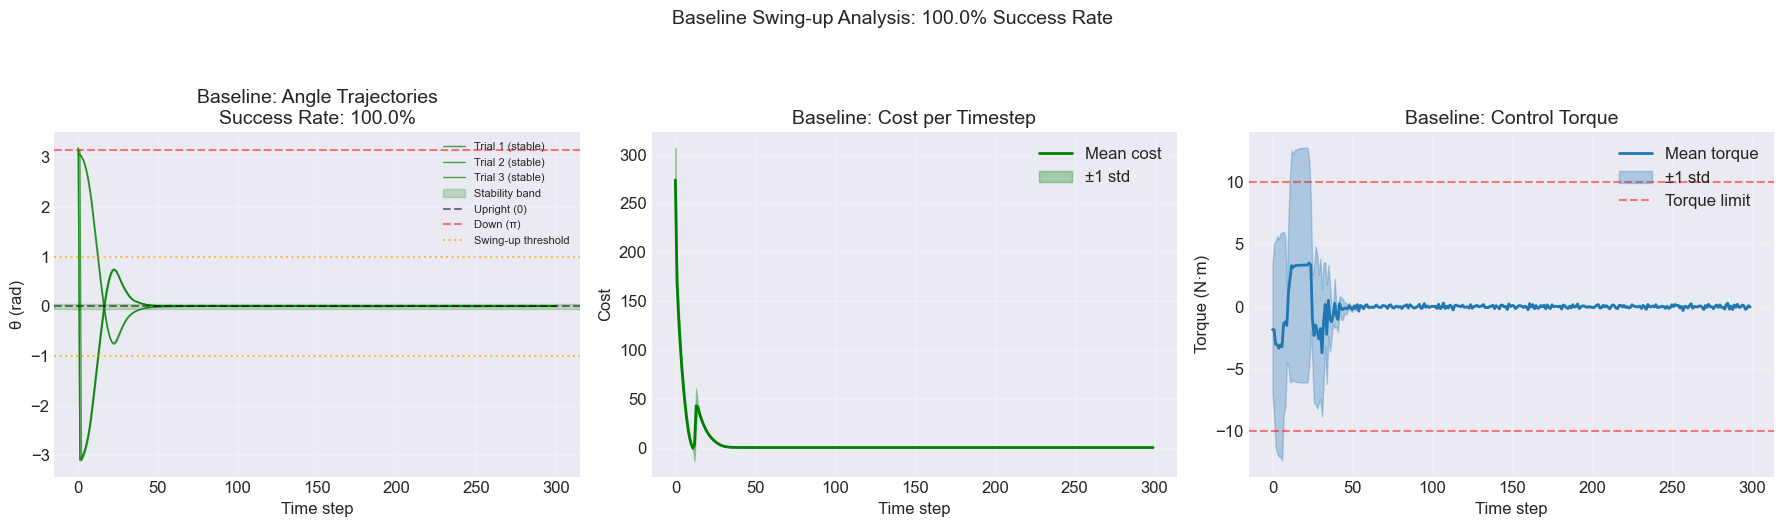

2. MODEL MISMATCH ANALYSIS

Running Mismatch: mass...
Testing mass mismatch with ratios: [1.5, 1.65, 1.75, 1.85, 2.0, 2.25, 2.5]
  Ratio 1.5:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 1.65:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 1.75:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 1.85:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 2.0:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Succ

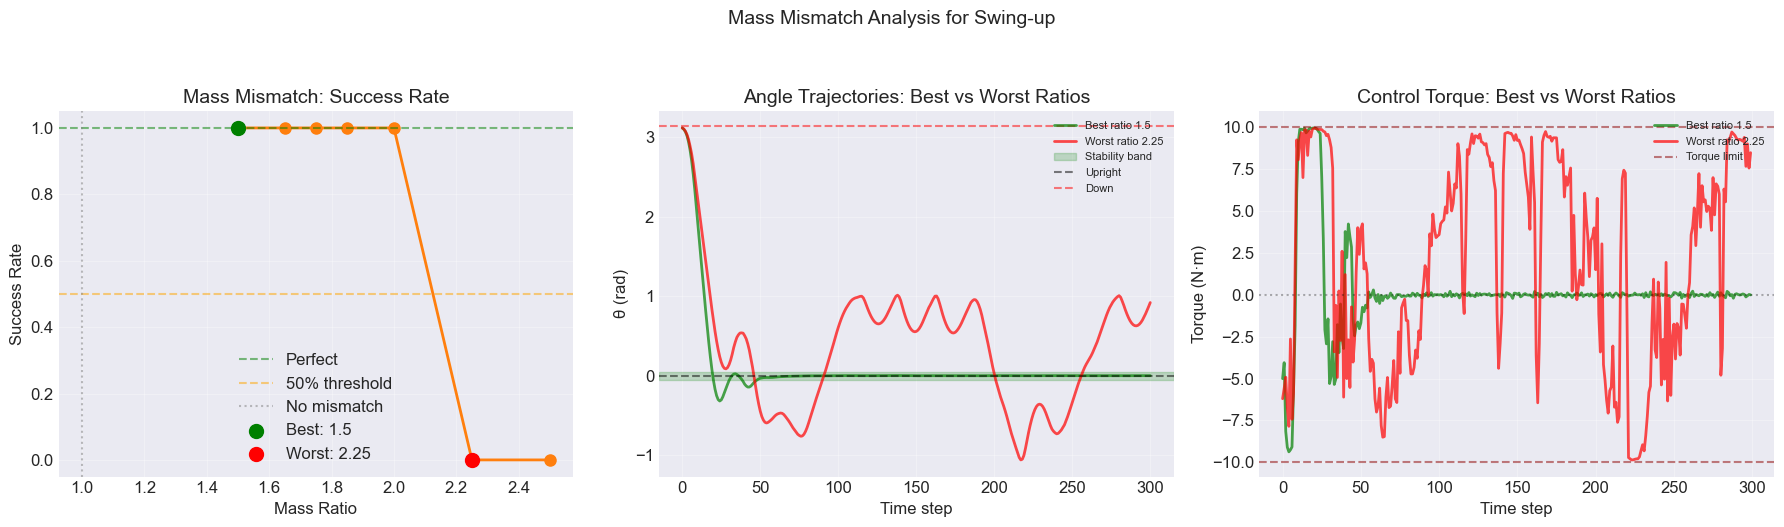


Running Mismatch: length...
Testing length mismatch with ratios: [1.1, 1.25, 1.35, 1.4, 1.5, 1.75, 2.0]
  Ratio 1.1:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 1.25:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 1.35:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 1.4:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 1.5:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 56.7%
  Ratio 1

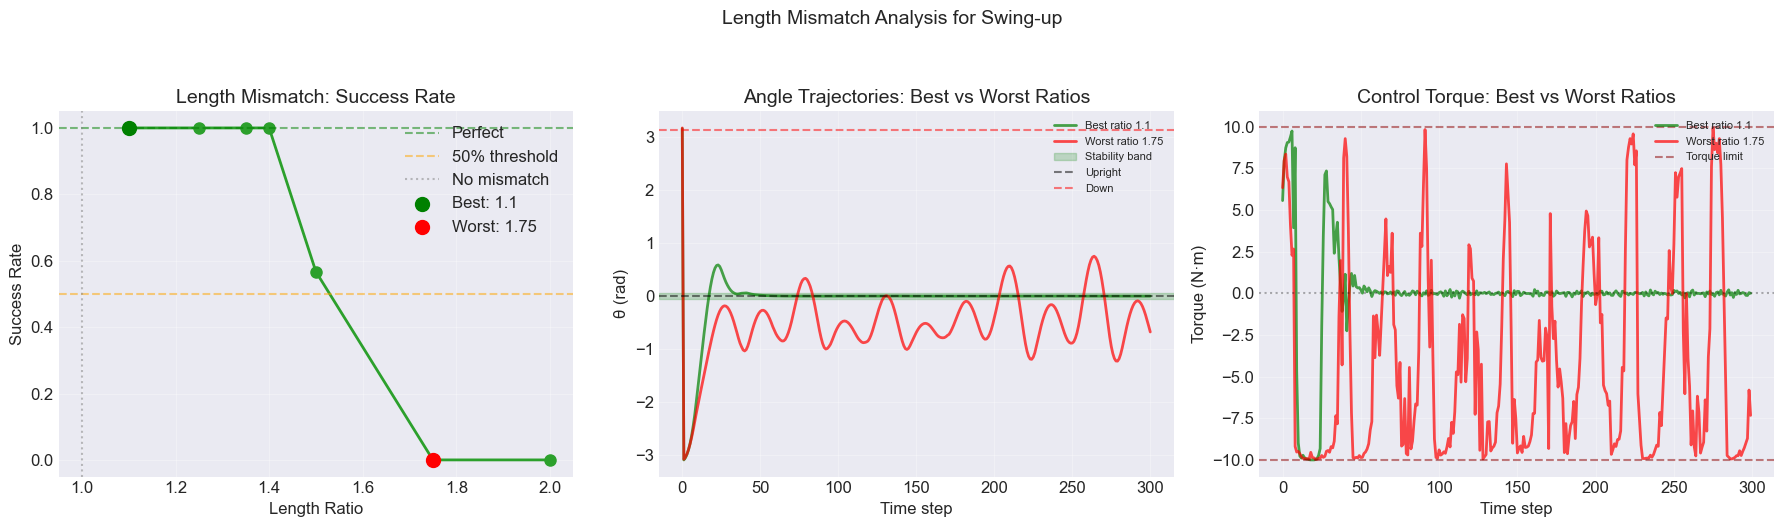


Running Mismatch: damping...
Testing damping mismatch with ratios: [1.0, 50.0, 100.0, 150.0, 200.0, 250.0, 300.0]
  Ratio 1.0:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 50.0:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Ratio 100.0:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 60.0%
  Ratio 150.0:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 0.0%
  Ratio 200.0:   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 0.0

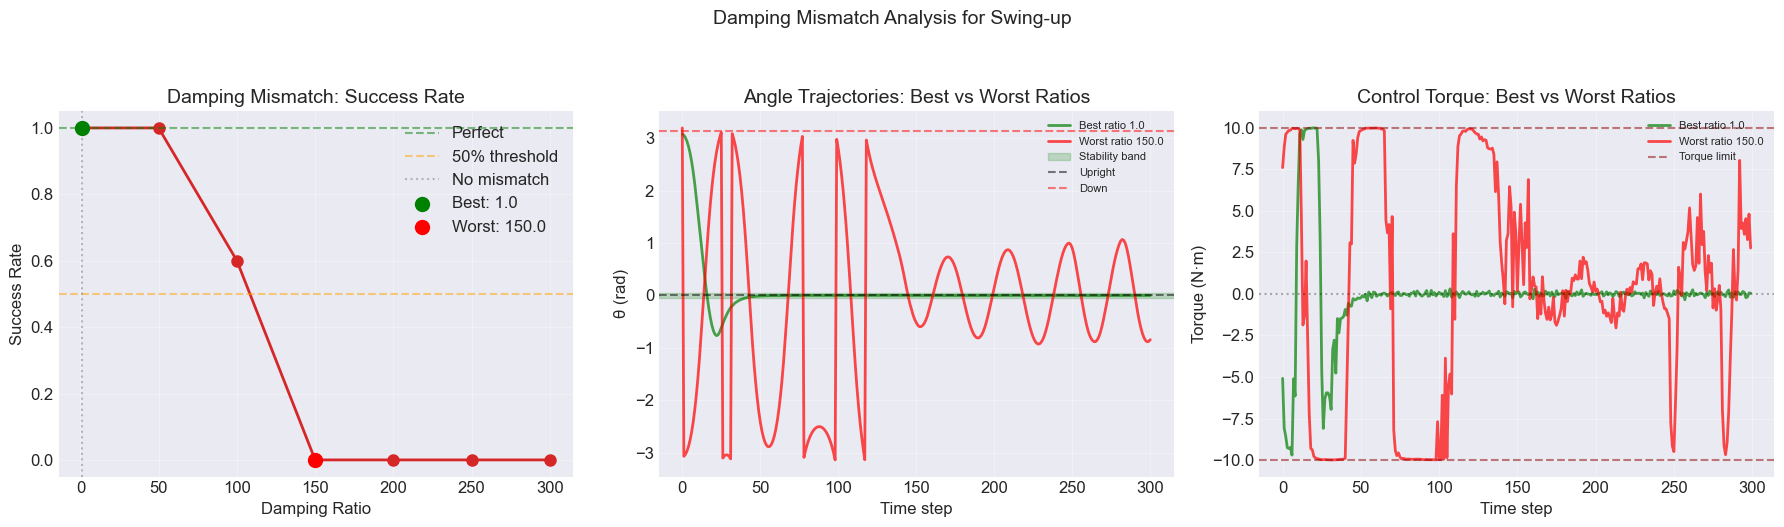

3. MEASUREMENT NOISE ANALYSIS

Running Observation Noise Only...
Testing 5 observation noise levels
  Observation noise (σ_θ=0.000, σ_θ_dot=0.000):   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Observation noise (σ_θ=0.050, σ_θ_dot=0.100):   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 96.7%
  Observation noise (σ_θ=0.100, σ_θ_dot=0.200):   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 0.0%
  Observation noise (σ_θ=0.150, σ_θ_dot=0.300):   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 0.0%
  Observation noise (σ_θ=0.200, σ_θ_dot=0.400):   Complet

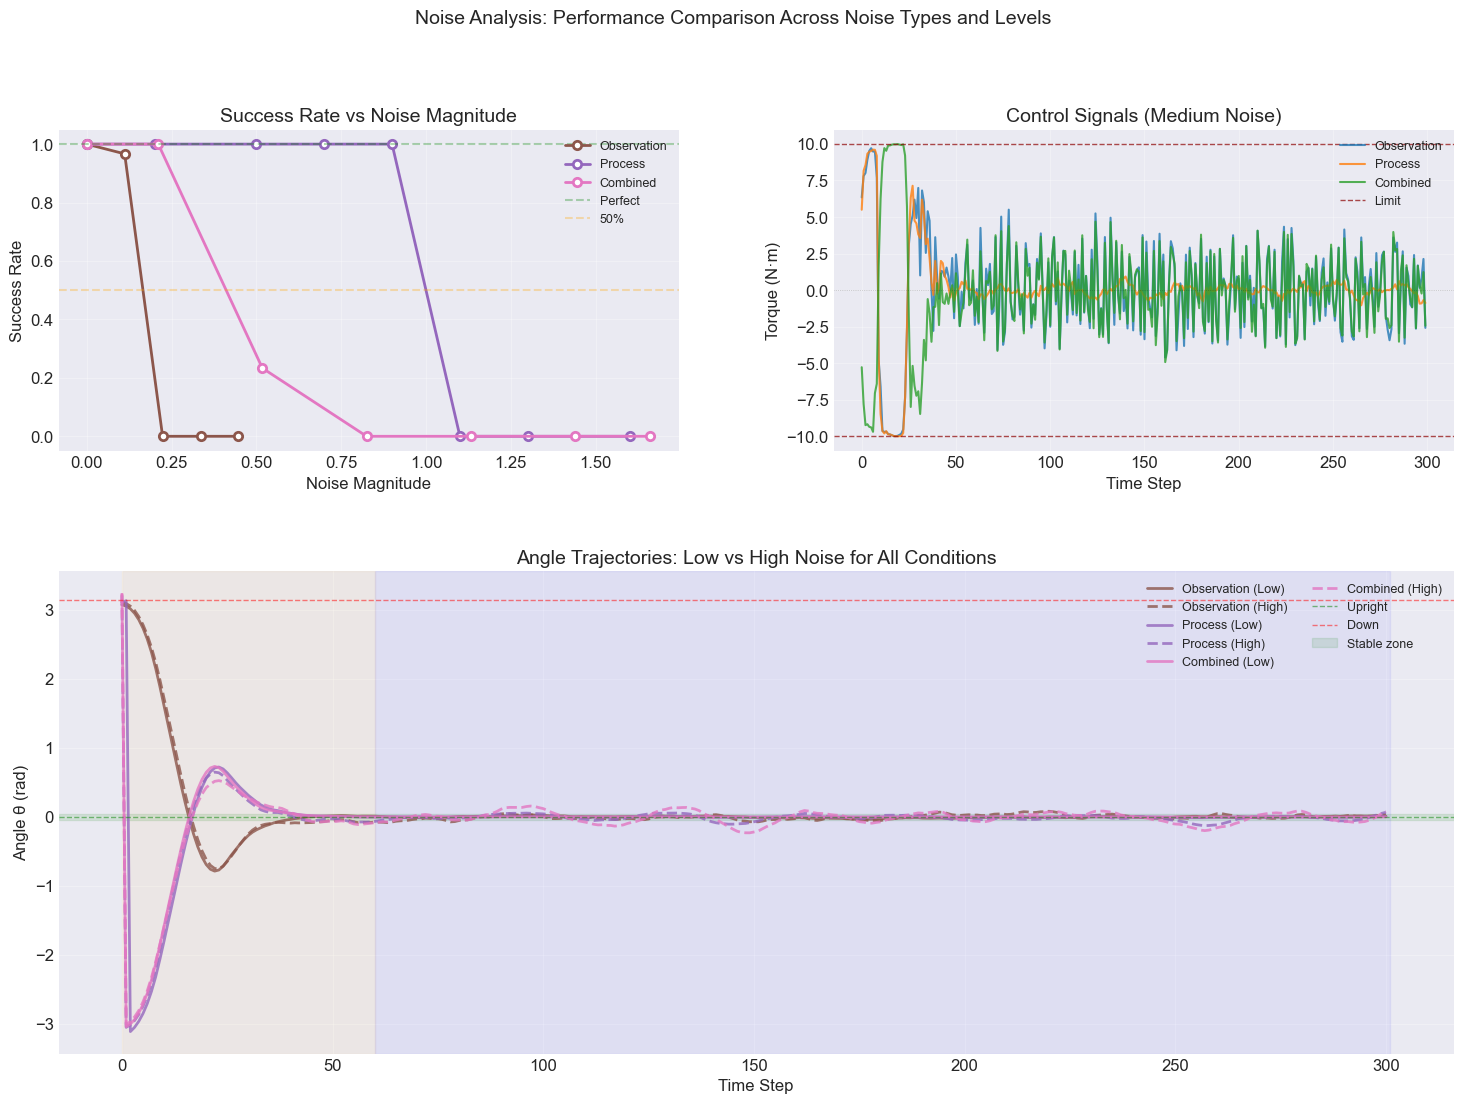

4. STRESS TEST (Mismatch + Noise)

Running Stress Test (Mismatch + Noise)...
Testing 9 stress profiles
Obs noise level: (0.08, 0.15)
Proc noise level (torque): 0.1
  Stress (m:1.6, l:1.3, d:100.0):   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 100.0%
  Stress (m:2.0, l:1.3, d:200.0):   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 30.0%
  Stress (m:1.6, l:1.3, d:150.0):   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 36.7%
  Stress (m:1.8, l:1.4, d:100.0):   Completed trial 5/30
  Completed trial 10/30
  Completed trial 15/30
  Completed trial 20/30
  Completed trial 25/30
  Completed trial 30/30
Success rate: 20.0%
  Stress (m:1.8, l:1.3, d:100.0):   Completed t

In [59]:
run_complete_analysis()


Running quick swing-up test...
1. BASELINE ANALYSIS (No mismatch, no noise)

Running Baseline (No Mismatch, No Noise)...
Experiment: Baseline (No Mismatch, No Noise)
Success rate: 100.0% (1/1)
Failure rate: 0.0%
Avg stabilization time (successful only): 45.0 ± nan steps
Avg normalized obs error (successful): 0.0000


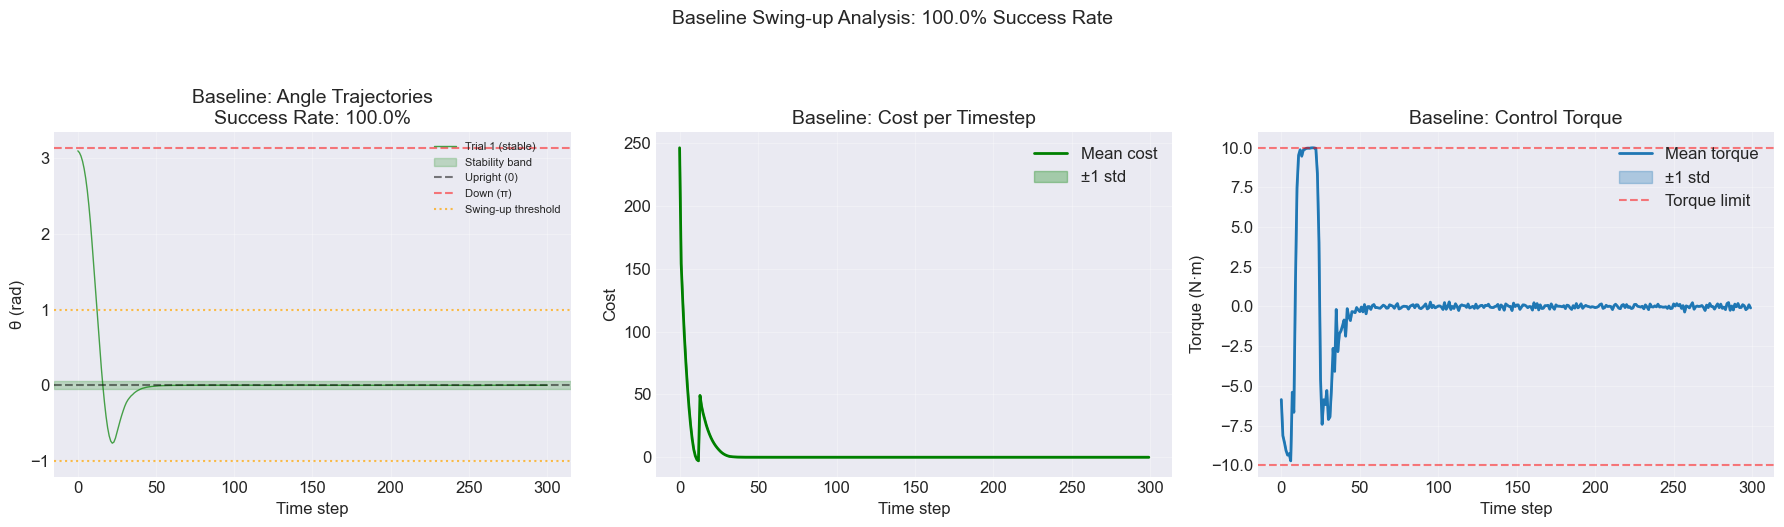

2. MODEL MISMATCH ANALYSIS

Running Mismatch: mass...
Testing mass mismatch with ratios: [1.5, 1.65, 1.75, 1.85, 2.0, 2.25, 2.5]
  Ratio 1.5: Success rate: 100.0%
  Ratio 1.65: Success rate: 100.0%
  Ratio 1.75: Success rate: 100.0%
  Ratio 1.85: Success rate: 100.0%
  Ratio 2.0: Success rate: 100.0%
  Ratio 2.25: Success rate: 0.0%
  Ratio 2.5: Success rate: 0.0%
Experiment: Mismatch: mass
Success rate: 71.4% (5/7)
Failure rate: 28.6%
Avg stabilization time (successful only): 68.6 ± 17.6 steps
Avg normalized obs error (successful): 0.0000
Avg normalized obs error (failed): 0.0000


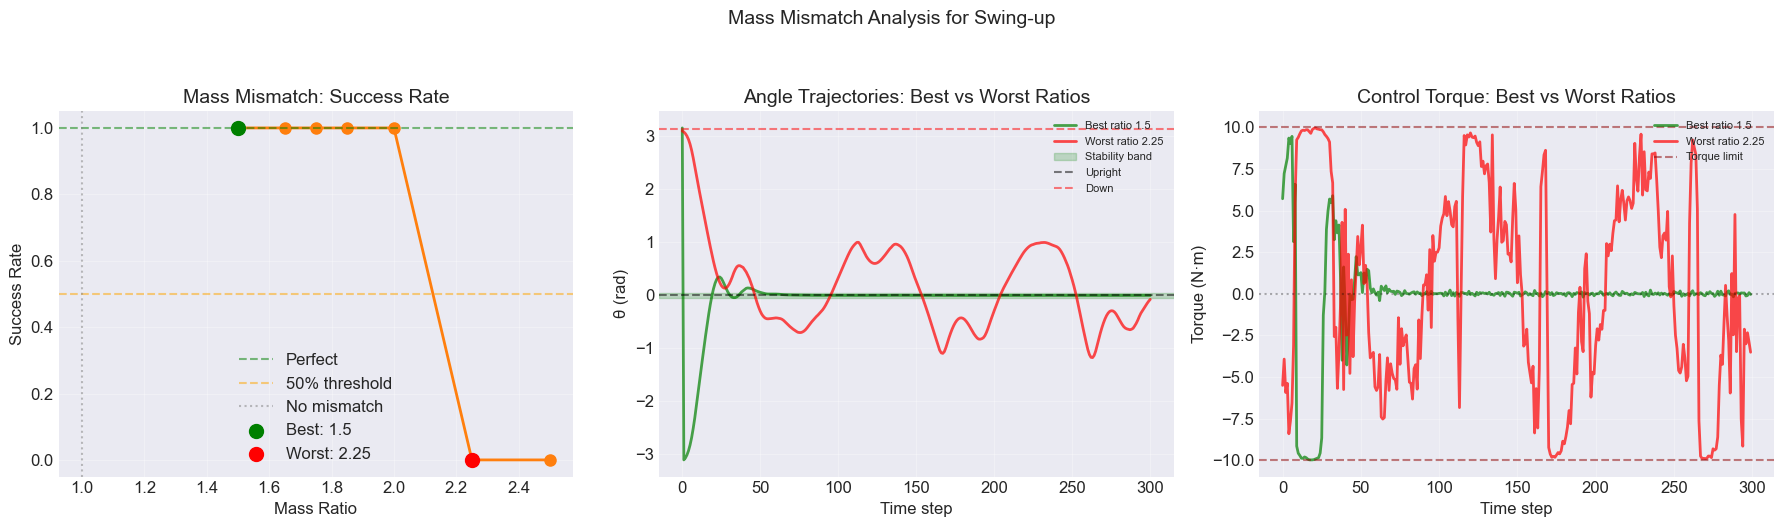


Running Mismatch: length...
Testing length mismatch with ratios: [1.1, 1.25, 1.35, 1.4, 1.5, 1.75, 2.0]
  Ratio 1.1: Success rate: 100.0%
  Ratio 1.25: Success rate: 100.0%
  Ratio 1.35: Success rate: 100.0%
  Ratio 1.4: Success rate: 100.0%
  Ratio 1.5: Success rate: 100.0%
  Ratio 1.75: Success rate: 0.0%
  Ratio 2.0: Success rate: 0.0%
Experiment: Mismatch: length
Success rate: 71.4% (5/7)
Failure rate: 28.6%
Avg stabilization time (successful only): 98.4 ± 47.2 steps
Avg normalized obs error (successful): 0.0000
Avg normalized obs error (failed): 0.0000


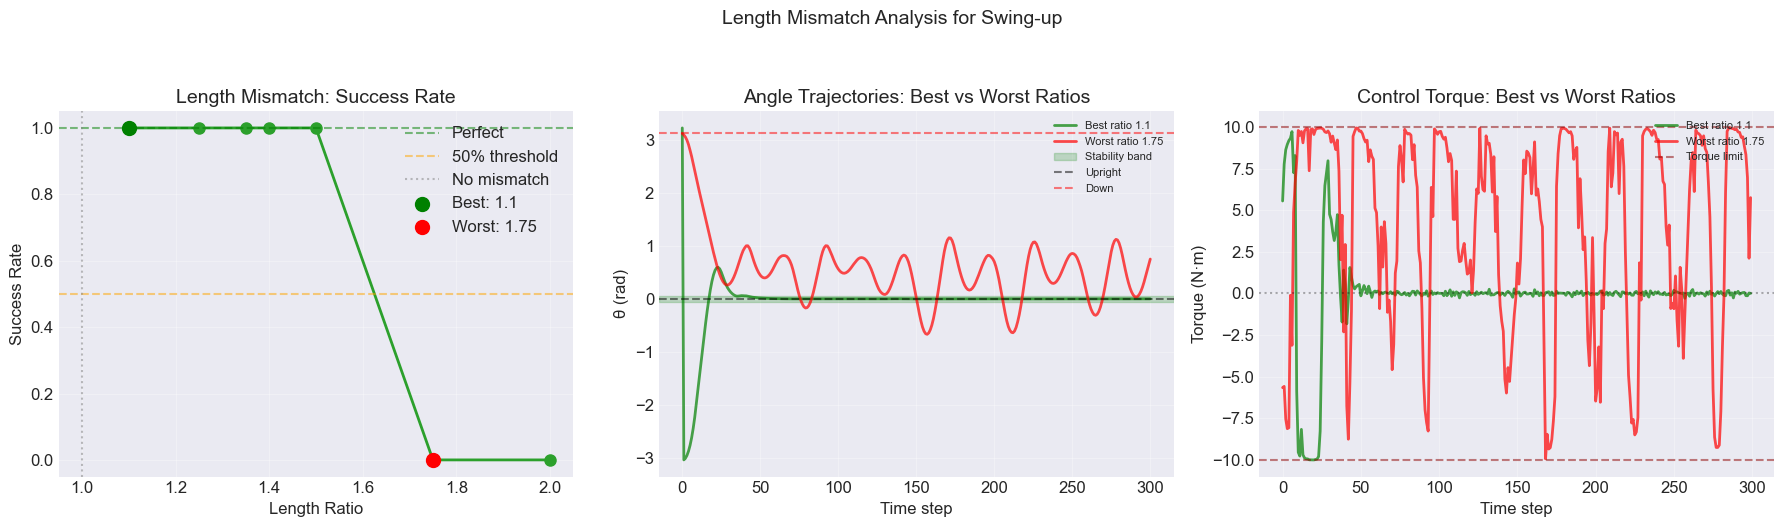


Running Mismatch: damping...
Testing damping mismatch with ratios: [1.0, 50.0, 100.0, 150.0, 200.0, 250.0, 300.0]
  Ratio 1.0: Success rate: 100.0%
  Ratio 50.0: Success rate: 100.0%
  Ratio 100.0: Success rate: 0.0%
  Ratio 150.0: Success rate: 0.0%
  Ratio 200.0: Success rate: 0.0%
  Ratio 250.0: Success rate: 0.0%
  Ratio 300.0: Success rate: 0.0%
Experiment: Mismatch: damping
Success rate: 28.6% (2/7)
Failure rate: 71.4%
Avg stabilization time (successful only): 73.0 ± 39.6 steps
Avg normalized obs error (successful): 0.0000
Avg normalized obs error (failed): 0.0000


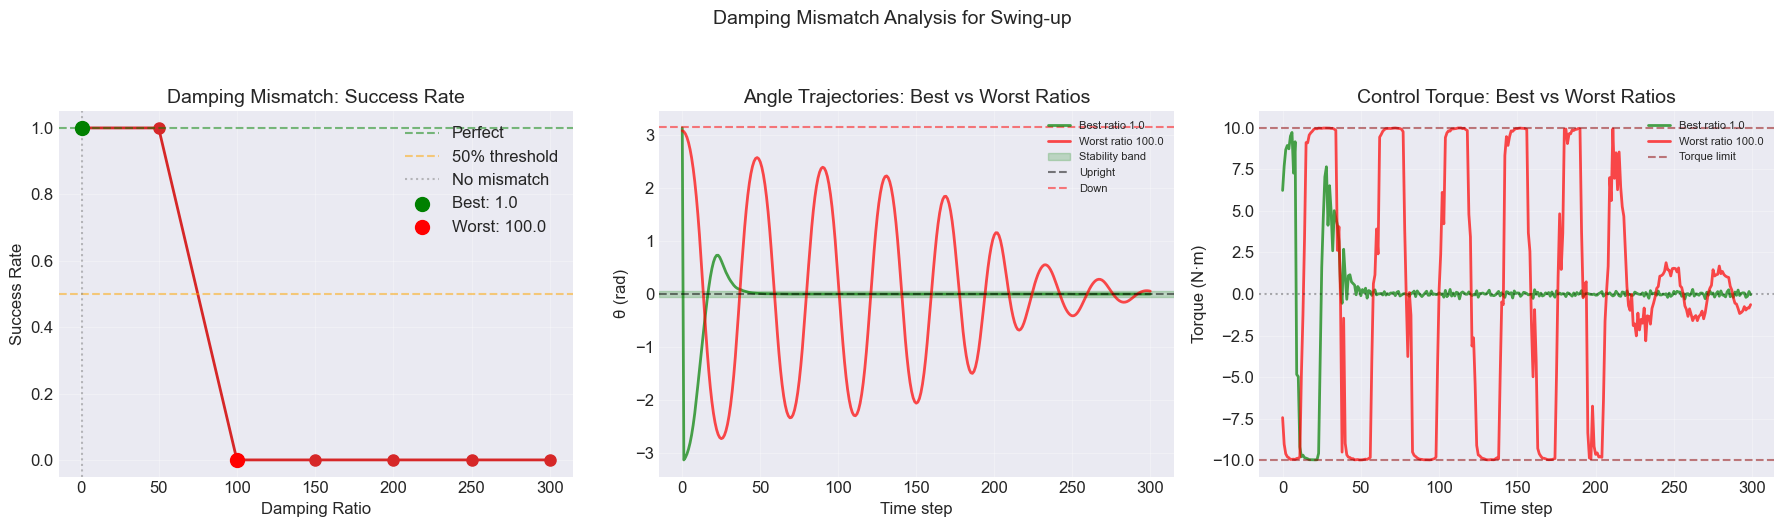

3. MEASUREMENT NOISE ANALYSIS

Running Observation Noise Only...
Testing 5 observation noise levels
  Observation noise (σ_θ=0.000, σ_θ_dot=0.000): Success rate: 100.0%
  Observation noise (σ_θ=0.050, σ_θ_dot=0.100): Success rate: 100.0%
  Observation noise (σ_θ=0.100, σ_θ_dot=0.200): Success rate: 0.0%
  Observation noise (σ_θ=0.150, σ_θ_dot=0.300): Success rate: 0.0%
  Observation noise (σ_θ=0.200, σ_θ_dot=0.400): Success rate: 0.0%
Experiment: Observation Noise Only
Success rate: 40.0% (2/5)
Failure rate: 60.0%
Avg stabilization time (successful only): 46.0 ± 1.4 steps
Avg normalized obs error (successful): 1.9385
Avg normalized obs error (failed): 4.3704

Running Process Noise Only...
Testing 8 process noise levels
  Process noise (torque σ=0.000 N·m): Success rate: 100.0%
  Process noise (torque σ=0.200 N·m): Success rate: 100.0%
  Process noise (torque σ=0.500 N·m): Success rate: 100.0%
  Process noise (torque σ=0.700 N·m): Success rate: 100.0%
  Process noise (torque σ=0.900 N·m

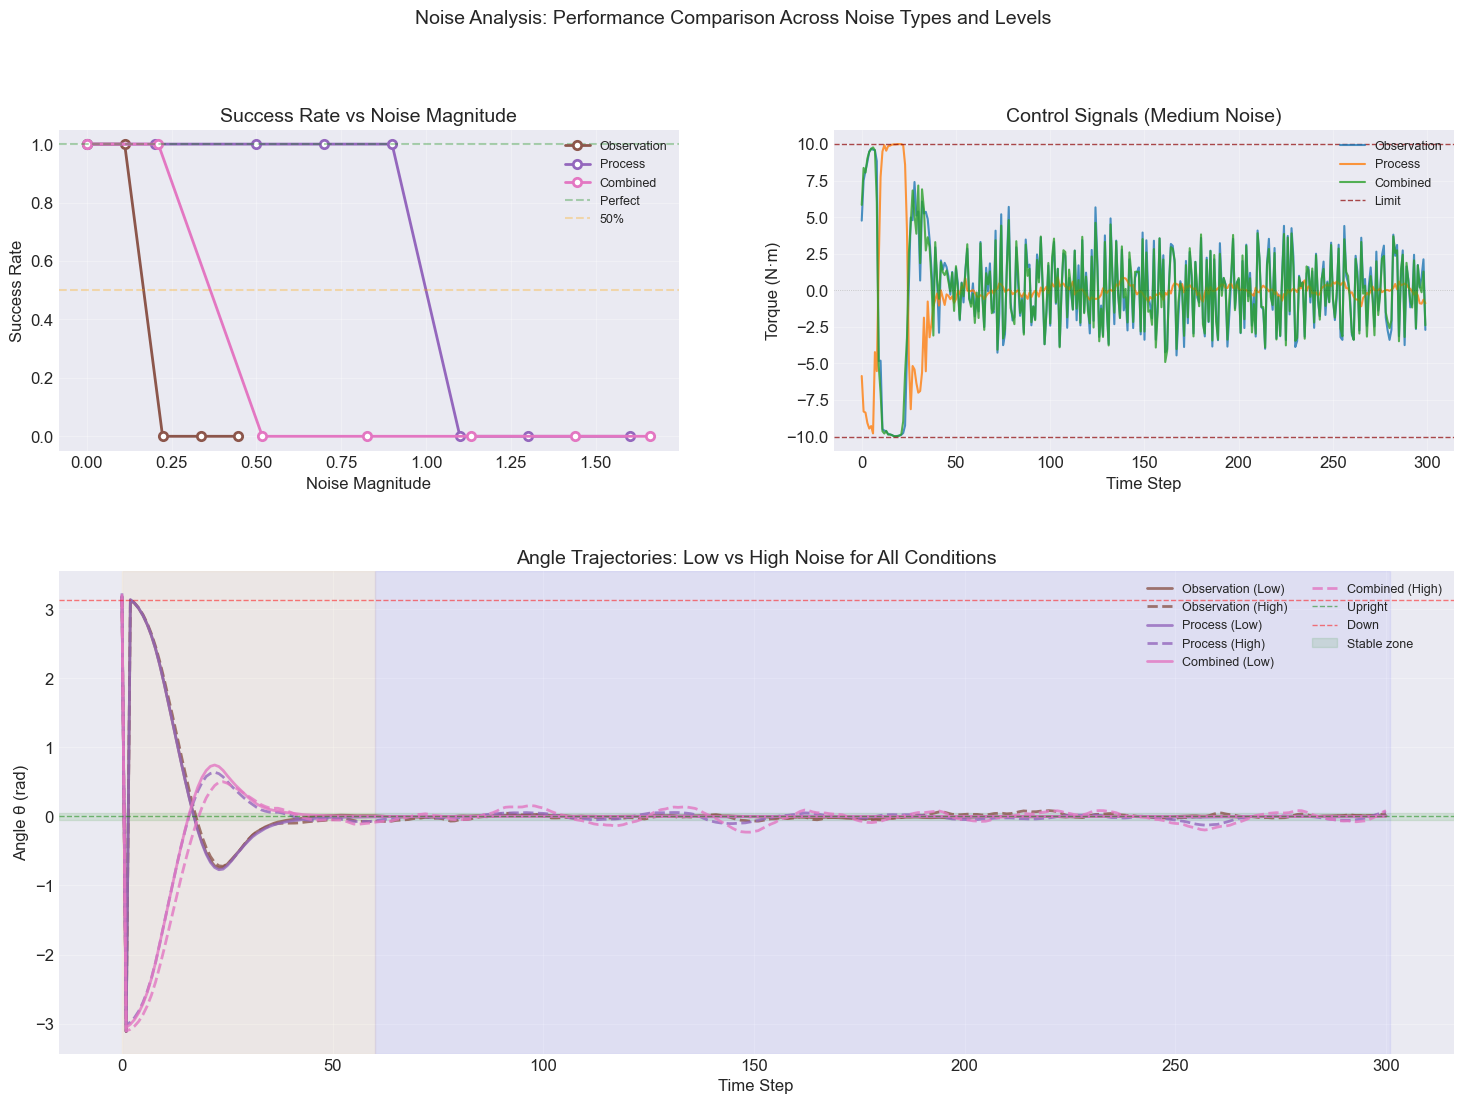

4. STRESS TEST (Mismatch + Noise)

Running Stress Test (Mismatch + Noise)...
Testing 9 stress profiles
Obs noise level: (0.08, 0.15)
Proc noise level (torque): 0.1
  Stress (m:1.6, l:1.3, d:100.0): Success rate: 100.0%
  Stress (m:2.0, l:1.3, d:200.0): Success rate: 0.0%
  Stress (m:1.6, l:1.3, d:150.0): Success rate: 0.0%
  Stress (m:1.8, l:1.4, d:100.0): Success rate: 0.0%
  Stress (m:1.8, l:1.3, d:100.0): Success rate: 100.0%
  Stress (m:1.8, l:1.3, d:150.0): Success rate: 0.0%
  Stress (m:1.6, l:1.4, d:100.0): Success rate: 0.0%
  Stress (m:1.8, l:1.5, d:150.0): Success rate: 0.0%
  Stress (m:2.0, l:1.5, d:200.0): Success rate: 0.0%
Experiment: Stress Test (Mismatch + Noise)
Success rate: 22.2% (2/9)
Failure rate: 77.8%
Avg stabilization time (successful only): 234.5 ± 26.2 steps
Avg normalized obs error (successful): 1.8748
Avg normalized obs error (failed): 2.4839


(<__main__.BaselineExperiment at 0x11b960080>,
  <__main__.CombinedNoiseExperiment at 0x1775cb830>])

In [60]:
quick_test()


### Results Analysis and Comparative Methodology

#### Baseline Performance
Under ideal conditions, the CEM-MPC controller achieves perfect 100% success rate, stabilizing the pendulum from the downward position in 44.7 ± 0.5 steps. This establishes a performance benchmark and confirms the controller's effectiveness for the nominal task.

#### Parameter Mismatch Analysis
The controller exhibits markedly different sensitivity to parameter errors:

**Mass mismatch** shows remarkable tolerance, maintaining 100% success up to **2.0×** the true mass before complete failure at 2.25×. This surprising robustness stems from mass appearing in both numerator (gravity torque: $mgl\sinθ$) and denominator (inertia: $ml^2$) of the dynamics, creating partial error cancellation. However, stabilization time increases significantly from 44.7 to 70.4 steps for successful cases, indicating controller strain.

**Length mismatch** is the most critical, with success dropping to 56.7% at just **1.5×** true length and complete failure at 1.75×. This extreme sensitivity arises because length affects the system in multiple ways:
1. **Quadratic effect on inertia**: $ml^2$ term in denominator
2. **Linear effect on gravity torque**: $mgl$ term
3. **Changes natural frequency**: $\omega_n = \sqrt{g/l}$

**Damping mismatch** demonstrates extraordinary tolerance, maintaining 100% success up to **50×** nominal damping, with some success (60%) even at 100×. This indicates the controller's phase-aware architecture can inject sufficient additional energy during swing-up to overcome excessive damping forces.

While its diffcult to have a precise comparison, since these values ofte have different ranges and units, we're are naively looking at how much ratio multiplication they can withstand in this case. For future projects it might be interesting to exapnd on this point.

#### Noise Sensitivity Analysis
**Observation noise** shows an abrupt threshold: 96.7% success at $(σ_θ=0.05, σ_{\dot{θ}}=0.10)$ but 0% at $(σ_θ=0.10, σ_{\dot{θ}}=0.20)$. The high normalized observation error in failures (3.7630 vs 0.6016 in successes) confirms that corrupted state information fundamentally degrades performance.

**Process noise** maintains 100% success up to **1.00 N·m** torque disturbance before collapsing at 1.10 N·m. Successful cases show moderate increase in stabilization time (44.7 to 61.6 steps) but no increase in observation error, suggesting the controller can compensate for physical disturbances when state measurements remain accurate.

**Combined noise** exhibits synergistic failure, with success dropping to 23.3% even at moderate levels $(σ_θ=0.06, σ_{\dot{θ}}=0.12, σ_u=0.50)$. This demonstrates that noise types interact non-linearly, creating greater challenges than their individual effects would suggest. This makes sense mathematically, since the first two were just addittive noise.

#### Mathematical Normalization for Comparison
Comparing sensitivity across different physical dimensions requires normalization:

1. **Parameter mismatch**: Express as dimensionless ratios ($m_{\text{actual}}/m_{\text{model}}$) with failure thresholds at:
   - Mass: 2.25×
   - Length: 1.75×
   - Damping: 100× (first significant failure)

2. **Observation noise**: Normalize by operational range:
   $$σ_{\text{norm}} = \frac{σ_θ}{π} \times 100\%$$
   Failure occurs at ~3.2% of full circle measurement range.

3. **Process noise**: Normalize by control authority:
   $$σ_{\text{norm}} = \frac{σ_u}{u_{\text{max}}} \times 100\%$$
   Failure occurs at ~11% of maximum control torque.

This normalized analysis reveals that **observation noise is approximately 3.4 times more critical than process noise** relative to their respective operational scales, highlighting that corrupted state information imposes stricter performance limits than equivalent physical disturbances.

#### Stress Test Analysis
Combined uncertainties yield an overall 39.3% success rate with severe performance degradation:
- Stabilization time increases **5×** (44.7 to 229.6 steps)
- Observation error increases dramatically (0.000 t0 2.040 for successes)
- Configurations with length ratios ≥ 1.5 consistently fail, reinforcing length as the dominant failure factor

This "reality gap" cost demonstrates that robust operation under uncertainty demands significant performance trade-offs. The phase-aware controller architecture provides some resilience but cannot fully compensate for severe combined uncertainties.

#### Theoretical Implications
The differential sensitivity aligns with control-theoretic principles:
1. **Length** affects both system gain (gravity torque) and natural frequency, creating complex error propagation through model predictions
2. **Mass** errors partially cancel in the dynamics equation
3. **Observation noise** corrupts the information state for decision-making, while **process noise** represents physical disturbances compensable via feedback
4. The sharp failure thresholds suggest practical limits to the controller's compensation ability, beyond which optimized sequences become ineffective

These results provide practical guidance for implementation: prioritize accurate length estimation and high-quality angle sensors, as these factors dominate robustness limits in sampling-based MPC for pendulum control.